<a href="https://colab.research.google.com/github/isaacadebayo/Predictive-Analytics-Public-Datasets/blob/main/Apple_Stock_prediction_timeseries_split_fold4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Error indicates a binary incompatibility between different Python packages, most likely between NumPy, SciPy, and Seaborn.
It often happens in environments like Colab when a package installation (like mlflow earlier) updates NumPy or its related dependencies in a way that conflicts with other already installed versions.
The best way to fix this is to reinstall NumPy, SciPy, and Seaborn to ensure they are built against compatible versions.

In [1]:
!pip install mlflow cryptography==43.0.3 --ignore-installed blinker


  Using cached mlflow-3.14.0-py3-none-any.whl.metadata (49 kB)
  Using cached cryptography-43.0.3-cp39-abi3-manylinux_2_28_x86_64.whl.metadata (5.4 kB)
  Using cached blinker-1.9.0-py3-none-any.whl.metadata (1.6 kB)
  Using cached cffi-2.0.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (2.6 kB)
  Using cached mlflow_skinny-3.14.0-py3-none-any.whl.metadata (50 kB)
  Using cached mlflow_tracing-3.14.0-py3-none-any.whl.metadata (19 kB)
  Using cached flask_cors-6.0.5-py3-none-any.whl.metadata (5.4 kB)
  Using cached flask-3.1.3-py3-none-any.whl.metadata (3.2 kB)
  Using cached aiohttp-3.14.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (8.3 kB)
  Using cached alembic-1.18.4-py3-none-any.whl.metadata (7.2 kB)
  Using cached docker-7.1.0-py3-none-any.whl.metadata (3.8 kB)
  Using cached graphene-3.4.3-py2.py3-none-any.whl.metadata (6.9 kB)
  Using cached gunicorn-26.0.0-py3-none-any.whl.metadata (5.4 kB)
  Using cached huey

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Reinstall numpy, scipy, and seaborn to resolve binary incompatibility issues
#!pip install --upgrade --force-reinstall numpy scipy seaborn

### What is MLflow?

MLflow is an open-source platform for managing the end-to-end machine learning lifecycle. It addresses four primary functions:

1.  **Tracking:** Record and query experiments (code, data, configuration, results).
2.  **Projects:** Package ML code in a reusable, reproducible form.
3.  **Models:** Manage ML models from various libraries and deploy them to diverse serving platforms.
4.  **Model Registry:** Store, annotate, discover, and manage models in a central repository.

To view the MLflow UI, you would typically run `!mlflow ui` in your terminal or a separate Colab cell if you have a local setup or a tracking server. In Colab, if you want to run `mlflow ui` within the notebook, you would typically need to expose a port, which is a bit more involved. For now, the focus is on logging.

### What is DVC?

DVC (Data Version Control) is an open-source version control system for machine learning projects. It makes ML projects reproducible by tracking machine learning models and datasets. DVC works alongside Git, allowing you to manage large files and directories as part of your Git repository without committing them directly to Git.

Key features include:

1.  **Data Versioning:** Version large datasets and models.
2.  **Experiment Management:** Track experiments by linking code, data, and models.
3.  **Reproducibility:** Recreate experiments by checking out specific data and model versions.
4.  **Pipeline Management:** Define and run data processing and ML pipelines.

In [3]:
# Install pyngrok to tunnel the MLflow UI
!pip install pyngrok

In [4]:
!pip install dvc[gdrive]

In [5]:
import os
from google.colab import userdata

# Get your ngrok authtoken from Colab secrets
NGROK_AUTH_TOKEN = userdata.get('NGROK_AUTH_TOKEN')

# Set the authtoken
!ngrok authtoken {NGROK_AUTH_TOKEN}

print("ngrok authtoken configured.")

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml
ngrok authtoken configured.


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Installing DVC

Let's install DVC. We'll use `dvc[gdrive]` for Google Drive integration, which is useful in Colab.

### Basic DVC Usage

To use DVC, you'll typically initialize a Git repository first, and then a DVC repository within it. For simplicity in Colab, we can skip the Git initialization if you only want to version data locally or with Google Drive as a remote. Let's set up a DVC remote to your Google Drive to store versioned data.

**Note:** You need to have git installed and initialize a git repo for DVC to work fully. If you haven't, please run !apt-get update && apt-get install git -y and then !git init in a separate cell before running the DVC commands.

**Setting up DVC with Google Drive:**

### Connecting Colab Git to GitHub

To connect your Colab environment to your GitHub repository, you'll need to configure Git with your user information and then either use an SSH key or a Personal Access Token (PAT) for authentication. Using a PAT is often simpler in Colab.

#### 1. Configure Git User Information

In [7]:
# Replace with your GitHub email and username
!git config --global user.email "isaac_adebayojr@gmail.com"
!git config --global user.name "isaacadebayo"

print("Git user configured.")

Git user configured.


#### 2. Authenticate with GitHub using a Personal Access Token (PAT)

GitHub requires authentication for many Git operations. A Personal Access Token (PAT) is a secure way to do this without exposing your password. If you don't have one, you can create it in your GitHub settings (Settings > Developer settings > Personal access tokens > Tokens (classic)). Give it the `repo` scope.

Once you have your PAT, you can use it to clone your repository.

In [8]:
# Store your GitHub PAT securely in Colab Secrets
# Click on the '🔑' icon on the left panel, add a new secret named 'GH_TOKEN' and paste your PAT there.
from google.colab import userdata
import os

# Get the PAT from Colab secrets
GH_TOKEN = userdata.get('GH_TOKEN')

# Set it as an environment variable (optional, but good practice if cloning private repos)
os.environ['GH_TOKEN'] = GH_TOKEN

print("GitHub Token retrieved. You can now use it for cloning private repositories.")

GitHub Token retrieved. You can now use it for cloning private repositories.


#### 3. Clone your GitHub Repository

Now you can clone your repository. For private repositories, you'll include your PAT in the URL.

In [9]:
# Replace 'your_username' and 'your_repository' with your actual GitHub details.
# For a public repository:
!git clone https://github.com/isaacadebayo/Predictive-Analytics-Public-Datasets.git

# For a private repository using PAT:
# This uses the GH_TOKEN environment variable
!git clone https://{GH_TOKEN}@github.com/isaacadebayo/Predictive-Analytics-Public-Datasets

# Change into your repository directory to perform Git operations
%cd Predictive-Analytics-Public-Datasets

print("Repository cloned. You are now in the repository directory.")

Cloning into 'Predictive-Analytics-Public-Datasets'...
remote: Enumerating objects: 213, done.
remote: Counting objects: 100% (75/75), done.
remote: Compressing objects: 100% (68/68), done.
remote: Total 213 (delta 30), reused 13 (delta 2), pack-reused 138 (from 1)
Receiving objects: 100% (213/213), 17.94 MiB | 30.72 MiB/s, done.
Resolving deltas: 100% (103/103), done.
fatal: destination path 'Predictive-Analytics-Public-Datasets' already exists and is not an empty directory.
/content/Predictive-Analytics-Public-Datasets
Repository cloned. You are now in the repository directory.


In [10]:
# Initialize DVC within the current directory (which is the cloned Git repo)
!dvc init

# Configure Google Drive as a remote storage (replace 'dvc_storage' with your desired folder name in Google Drive)
!dvc remote add -d gdrive_remote gdrive://MyDrive/dvc_storage
!dvc remote add -d gcs_remote gs://my-agentic-chatbot-data-lake

# Create a data directory within the Git repository if it doesn't exist
!mkdir -p data

# Copy the data file into the Git repository's data directory
# This ensures the .dvc file (created by dvc add) will be within the Git repo
!cp /content/drive/MyDrive/aapl_stock_prices.csv data/aapl_stock_prices.csv

# Add a data file to DVC. This will create a .dvc file at data/aapl_stock_prices.csv.dvc
!dvc add data/aapl_stock_prices.csv

# To commit the .dvc file to Git (requires Git setup, which is already done)
# Now git will find the .dvc file within its repository's working directory
!git add data/aapl_stock_prices.csv.dvc
!git commit -m "Add aapl_stock_prices.csv to DVC"

print("DVC setup complete. Your data file is now versioned with DVC and stored in Google Drive.")
print("You can push/pull changes using: !dvc push and !dvc pull")

ERROR: failed to initiate DVC - '.dvc' exists. Use `-f` to force.
Setting 'gdrive_remote' as a default remote.
ERROR: configuration error - config file error: remote 'gdrive_remote' already exists. Use `-f|--force` to overwrite it.
Setting 'gcs_remote' as a default remote.
ERROR: configuration error - config file error: remote 'gcs_remote' already exists. Use `-f|--force` to overwrite it.
⠋ Checking graph
Adding...:   0% 0/1 [00:00<?, ?file/s{'info': ''}]
!
          |0.00 [00:00,     ?file/s]
                                    
!
  0% |          |0/? [00:00<?,    ?files/s]
                                           
Adding data/aapl_stock_prices.csv to cache:   0% 0/1 [00:00<?, ?file/s]
  0% 0/1 [00:00<?, ?file/s{'info': ''}]                                
                                       
  0% 0/1 [00:00<?, ?files/s]
  0% 0/1 [00:00<?, ?files/s{'info': ''}]
Adding...: 100% 1/1 [00:00<00:00, 35.30file/s{'info': ''}]

To track the changes with git, run:

	git add data/aapl_stoc

In [11]:
# Stage all changes in the current directory
!git add .

# Commit the staged changes with a message
# Replace 'Your insightful commit message' with a description of your changes
!git commit -m "Testing commit from colab to github"

# Push the changes to the 'main' branch of your remote repository
# This uses the GH_TOKEN environment variable for authentication
!git push https://{GH_TOKEN}@github.com/isaacadebayo/Predictive-Analytics-Public-Datasets.git main

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
Everything up-to-date


In [12]:
print('Contents of the cloned repository:')
!ls -F

Contents of the cloned repository:
 Apple_Stock_prediction.ipynb
 Apple_Stock_prediction_timeseries_split_fold4.ipynb
 Apple_Stock_prediction_timeseries_split.ipynb
 data/
'Fraud_detection_highEvalMatrix_(1).ipynb'
 Fraud_detection_highEvalMatrix_FINAL.ipynb
 Fraud_detection_highEvalMatrix.ipynb
 Fraud_detection.ipynb
'GRADIO_Multimodal_Chatbot_Longevity_ No_API_KEY.ipynb'
 Image_Generation_using_gpt_image_1.ipynb
 Model_finetuning_mistral_ai.ipynb
 project/
 RAG_Finanicial_Audio_Chatbot_Original_No_API_KEY.ipynb
 RAG_Finanicial_Chatbot_Original_NoAPI_Key.ipynb
 README.md
 Time_Series_Financial_NYSE.ipynb
 Unsupervised_learning_Clustering_Credit_Card_Analysis.ipynb
 Visual_Transformer_and_CNN.ipynb
 visual_transformer_and_cnn.py
 WHISPER_Audio_Transformer.ipynb


After these steps, you can use standard `!git` commands (e.g., `!git add .`, `!git commit -m "Message"`, `!git push origin main`) to interact with your GitHub repository from Colab.

### More on DVC

*   DVC and dataset integrity alteration: DVC focuses on dataset integrity and preventing alteration. Its core purpose is to version control data just like Git version controls code
*   Purpose of .dvc file with cloud storage . dvc does not store the actual data itself instead it is a small human readable text file that contains metadata about data file such as path of originl data file, hash checksum of the data file and a pointer to the locaiton of the actual data in my remote storage





In [13]:
stocks = pd.read_csv('/content/drive/MyDrive/aapl_stock_prices.csv')
stocks.head()

,Date,Open,High,Low,Close,Volume
0,1980-12-12,0.098297,0.098725,0.098297,0.098297,469033600
1,1980-12-15,0.093597,0.093597,0.093169,0.093169,175884800
2,1980-12-16,0.086758,0.086758,0.086331,0.086331,105728000
3,1980-12-17,0.088468,0.088895,0.088468,0.088468,86441600
4,1980-12-18,0.091032,0.091460,0.091032,0.091032,73449600


# Feature Engineering

Moving average price

In [14]:
stocks['Moving_Average'] = stocks['Close'].rolling(window=50).mean()

stocks

,Date,Open,High,Low,Close,Volume,Moving_Average
0,1980-12-12,0.098297,0.098725,0.098297,0.098297,469033600,NaN
1,1980-12-15,0.093597,0.093597,0.093169,0.093169,175884800,NaN
2,1980-12-16,0.086758,0.086758,0.086331,0.086331,105728000,NaN
3,1980-12-17,0.088468,0.088895,0.088468,0.088468,86441600,NaN
4,1980-12-18,0.091032,0.091460,0.091032,0.091032,73449600,NaN
...,...,...,...,...,...,...,...
11402,2026-03-12,258.660004,258.950012,254.179993,255.759995,40794000,263.034650
11403,2026-03-13,255.479996,256.329987,249.520004,250.119995,36930000,262.580556
11404,2026-03-16,252.110001,253.889999,249.880005,252.820007,32074200,262.204839
11405,2026-03-17,252.960007,255.130005,252.179993,254.229996,32361600,261.874306


Difference in price

In [15]:
delta = stocks['Close'].diff()
delta

,Close
0,NaN
1,-0.005128
2,-0.006838
3,0.002137
4,0.002565
...,...
11402,-5.050003
11403,-5.639999
11404,2.700012
11405,1.409988


Separate calculated gain and losses

In [16]:
gain = delta.clip(lower=0)
loss = -1 * delta.clip(upper=0)

Calculate Exponential moving average

In [17]:
avg_gain = gain.ewm(com=14, min_periods=14, adjust=False).mean()
avg_loss = loss.ewm(com=14, min_periods=14, adjust=False).mean()

avg_loss

,Close
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
11402,1.726921
11403,1.987793
11404,1.855273
11405,1.731588


In [18]:
rs = avg_gain / avg_loss
rsi = 100 - (100 / (1 + rs))

stocks['RSI'] = rsi
stocks.head()

,Date,Open,High,Low,Close,Volume,Moving_Average,RSI
0,1980-12-12,0.098297,0.098725,0.098297,0.098297,469033600,NaN,NaN
1,1980-12-15,0.093597,0.093597,0.093169,0.093169,175884800,NaN,NaN
2,1980-12-16,0.086758,0.086758,0.086331,0.086331,105728000,NaN,NaN
3,1980-12-17,0.088468,0.088895,0.088468,0.088468,86441600,NaN,NaN
4,1980-12-18,0.091032,0.091460,0.091032,0.091032,73449600,NaN,NaN


Drop first 50 rows to incorporate moving average column and prevent skewing the data

In [19]:
stocks.isna().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Volume,0
Moving_Average,49
RSI,14


In [20]:
stocks.drop(index=stocks.index[:50], inplace=True)
stocks.head()

,Date,Open,High,Low,Close,Volume,Moving_Average,RSI
50,1981-02-25,0.086331,0.086758,0.086331,0.086331,19488000,0.101298,38.088629
51,1981-02-26,0.087613,0.088040,0.087613,0.087613,10841600,0.101187,39.855881
52,1981-02-27,0.090605,0.091460,0.090605,0.090605,14761600,0.101272,43.863024
53,1981-03-02,0.091032,0.091460,0.091032,0.091032,11760000,0.101324,44.429548
54,1981-03-03,0.090178,0.090178,0.089750,0.089750,16172800,0.101298,43.033586


In [21]:
stocks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11357 entries, 50 to 11406
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            11357 non-null  object 
 1   Open            11357 non-null  float64
 2   High            11357 non-null  float64
 3   Low             11357 non-null  float64
 4   Close           11357 non-null  float64
 5   Volume          11357 non-null  int64  
 6   Moving_Average  11357 non-null  float64
 7   RSI             11357 non-null  float64
dtypes: float64(6), int64(1), object(1)
memory usage: 709.9+ KB


<Axes: xlabel='Date'>

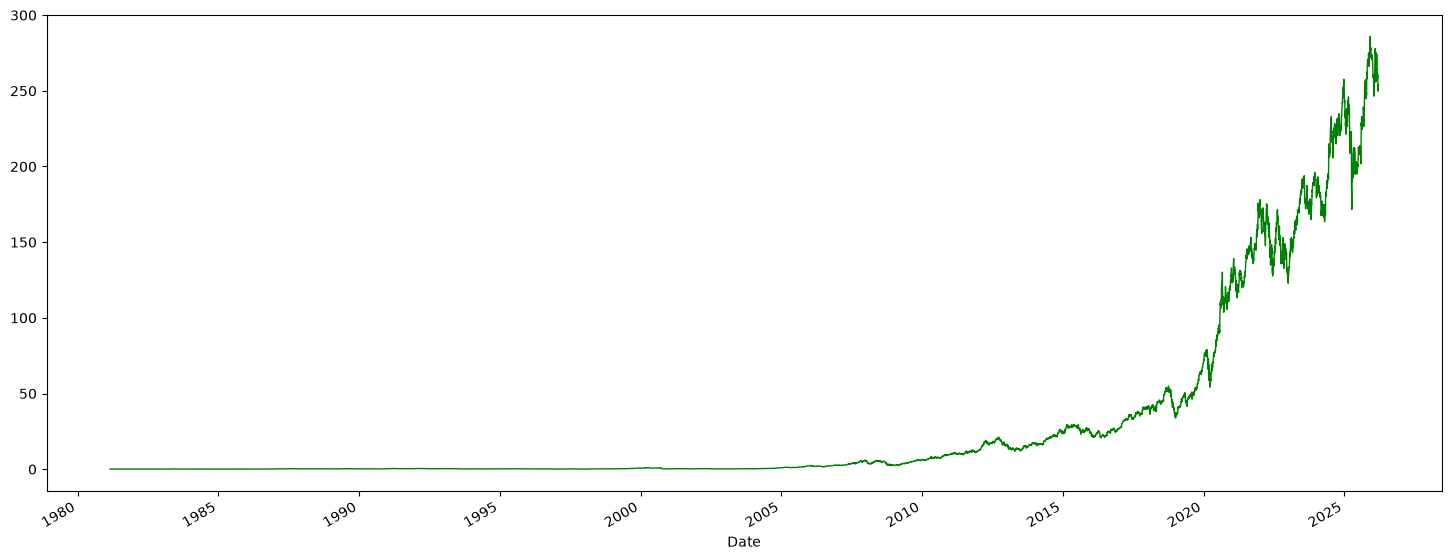

In [22]:
if 'Date' in stocks.columns:
    stocks['Date'] = pd.to_datetime(stocks['Date'])
    stocks = stocks.set_index('Date')
stocks.Close.plot(figsize=(18,7), linewidth=1, c='g')

In [23]:
# Create lagged sequences
window_size = 10

#perm = np.arange(window_size)
perm = np.random.permutation(np.arange(window_size))

X, y = [], []
dates = []
for i in range(len(stocks) - window_size):
    X.append(stocks.iloc[i:i+window_size].values)
    # Predict only the 'close' price (index 1) for y
    y.append(stocks.iloc[i+window_size, 1])
    dates.append(stocks.index[i+window_size])

X = np.array(X)
y = np.array(y)
dates = np.array(dates)

print(f"X shape: {X.shape}, y shape: {y.shape}")

X shape: (11347, 10, 7), y shape: (11347,)


In [24]:
# one temporal split, used by everyone
split_idx    = int(len(X) * 0.8)
X_train_3d   = X[:split_idx]       # for LSTM (3D)
X_test_3d    = X[split_idx:]
X_train_2d   = X_train_3d.reshape(X_train_3d.shape[0], -1)  # for sklearn + Dense
X_test_2d    = X_test_3d.reshape(X_test_3d.shape[0], -1)
y_train      = y[:split_idx]
y_test       = y[split_idx:]
dates_train  = dates[:split_idx]
dates_test   = dates[split_idx:]

print(f"Train: X={X_train_3d.shape}, y={y_train.shape}")
print(f"Test:  X={X_test_3d.shape}, y={y_test.shape}")
print(f"Train: X={X_train_2d.shape}, y={y_train.shape}")
print(f"Test:  X={X_test_2d.shape}, y={y_test.shape}")
print(f"Train: X={dates_train.shape}, y={y_train.shape}")
print(f"Test:  X={dates_test.shape}, y={y_test.shape}")


Train: X=(9077, 10, 7), y=(9077,)
Test:  X=(2270, 10, 7), y=(2270,)
Train: X=(9077, 70), y=(9077,)
Test:  X=(2270, 70), y=(2270,)
Train: X=(9077,), y=(9077,)
Test:  X=(2270,), y=(2270,)


In [25]:

from sklearn.preprocessing import MinMaxScaler
# one scaler, fit on train only, used by Keras pipelines
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X_train_scaled_2d = scaler_X.fit_transform(X_train_2d)
X_test_scaled_2d   = scaler_X.transform(X_test_2d)
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1,1))
y_test_scaled  = scaler_y.transform(y_test.reshape(-1,1))
# reshape scaled 2D back to 3D
X_train_scaled_3d = X_train_scaled_2d.reshape(X_train_3d.shape)
X_test_scaled_3d  = X_test_scaled_2d.reshape(X_test_3d.shape)

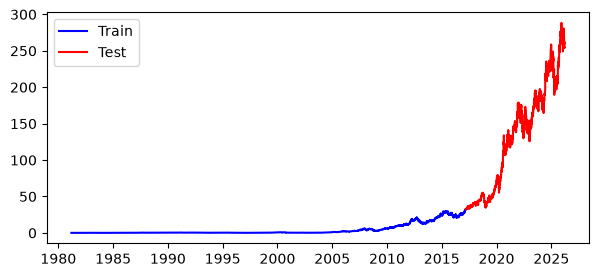

In [26]:
plt.figure(figsize=(7,3))
# y_train and y_test are now 1D arrays
plt.plot( dates_train, y_train, 'b', label='Train' );
plt.plot( dates_test, y_test, 'r', label='Test' );
plt.legend()

In [27]:
'''# Simple index-based split
split_idx = int(len(X) * 0.9)
X_train, y_train, dates_train = X[:split_idx], y[:split_idx], dates[:split_idx]
X_test, y_test, dates_test = X[split_idx:], y[split_idx:], dates[split_idx:]

# Reshape X_train and X_test to be 2D for scikit-learn models
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

print(f"Train: X={X_train.shape}, y={y_train.shape}")
print(f"Test:  X={X_test.shape}, y={y_test.shape}")'''

'# Simple index-based split\nsplit_idx = int(len(X) * 0.9)\nX_train, y_train, dates_train = X[:split_idx], y[:split_idx], dates[:split_idx]\nX_test, y_test, dates_test = X[split_idx:], y[split_idx:], dates[split_idx:]\n\n# Reshape X_train and X_test to be 2D for scikit-learn models\nX_train = X_train.reshape(X_train.shape[0], -1)\nX_test = X_test.reshape(X_test.shape[0], -1)\n\nprint(f"Train: X={X_train.shape}, y={y_train.shape}")\nprint(f"Test:  X={X_test.shape}, y={y_test.shape}")'

# Cross Validation

In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

models = [
    LinearRegression(),
    KNeighborsRegressor(n_neighbors=4, weights='uniform'),
    RandomForestRegressor(n_estimators=10, max_depth=5),
    RandomForestRegressor(n_estimators=30, max_depth=10),
    GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=2),
    GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3),
    GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5),
]

In [29]:
from sklearn.model_selection import cross_val_score, KFold, TimeSeriesSplit

#kf = KFold(n_splits=5, shuffle=True)
kf = TimeSeriesSplit(n_splits=5)

# Reshape X to be 2-dimensional for scikit-learn models
X_2d = X.reshape(X.shape[0], -1)

for m in models:
    print(m)

    cv_scores = -cross_val_score(m, X_2d, y, cv=kf, scoring='neg_mean_absolute_percentage_error')
    cv_scores = pd.DataFrame(cv_scores)
    display(cv_scores.describe().T)

    print()
# end

LinearRegression()


,count,mean,std,min,25%,50%,75%,max
0,5.0,0.703848,0.258961,0.378664,0.497069,0.751136,0.941192,0.951179


Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x7c3db9a385e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1187, in _make_controller_from_path
    lib_controller = controller_class(
                     ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/ctypes/__init__.py", line 379, in __init__
    self._handle = _dlopen(self._name, mode)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^
OSError: dlopen() error



KNeighborsRegressor(n_neighbors=4)


,count,mean,std,min,25%,50%,75%,max
0,5.0,0.681119,0.222503,0.41377,0.477388,0.771587,0.824351,0.918497


...

,count,mean,std,min,25%,50%,75%,max
0,5.0,0.326416,0.254202,0.028998,0.071387,0.465343,0.52377,0.542582



GradientBoostingRegressor()


,count,mean,std,min,25%,50%,75%,max
0,5.0,0.324744,0.253449,0.029193,0.069214,0.466007,0.51611,0.543198



GradientBoostingRegressor(max_depth=5)


,count,mean,std,min,25%,50%,75%,max
0,5.0,0.327337,0.255405,0.029309,0.069982,0.468187,0.527005,0.542204


# Grid SearchCV

In [30]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# Define models and their parameter grids
param_grids = {
    "KNeighborsRegressor": (
        KNeighborsRegressor(),
        {
            "n_neighbors": [1, 5, 10, 20, 50],
            "weights": ["uniform", "distance"]
        }
    ),

    "RandomForestRegressor": (
        RandomForestRegressor(),
        {
            "n_estimators": [10, 50, 100],
            "max_depth": [3, 5, 10],
            "min_samples_split": [2, 5, 10],
            'min_samples_leaf': [1, 2, 5, 10]
        }
    ),

    "GradientBoostingRegressor": (
        GradientBoostingRegressor(),
        {
            "n_estimators": [50, 100, 200],
            "learning_rate": [0.01, 0.1, 0.2],
            "max_depth": [2, 3, 5],
            'min_samples_leaf': [1, 2, 5, 10]
        }
    )
}

# Define cross-validation strategy
#kf = KFold(n_splits=5, shuffle=True)
kf = TimeSeriesSplit(n_splits=5)

# Store results
results = []

# Perform GridSearchCV for each model
for name, (model, param_grid) in param_grids.items():
    print(f"Performing GridSearchCV for {name}...")

    grid_search = GridSearchCV(model, param_grid, cv=kf, scoring="neg_mean_absolute_percentage_error", n_jobs=-1)
    grid_search.fit(X_2d, y)

    best_params = grid_search.best_params_
    best_score = grid_search.best_score_

    results.append({"Model": name, "Best Score": best_score, "Best Params": best_params})
# end

results

Performing GridSearchCV for KNeighborsRegressor...
Performing GridSearchCV for RandomForestRegressor...
Performing GridSearchCV for GradientBoostingRegressor...


[{'Model': 'KNeighborsRegressor',
  'Best Score': np.float64(-0.6663154674458628),
  'Best Params': {'n_neighbors': 50, 'weights': 'uniform'}},
 {'Model': 'RandomForestRegressor',
  'Best Score': np.float64(-0.32671508939510335),
  'Best Params': {'max_depth': 10,
   'min_samples_leaf': 2,
   'min_samples_split': 2,
   'n_estimators': 50}},
 {'Model': 'GradientBoostingRegressor',
  'Best Score': np.float64(-0.3247290407462674),
  'Best Params': {'learning_rate': 0.1,
   'max_depth': 2,
   'min_samples_leaf': 2,
   'n_estimators': 200}}]

# Feature Importance










In [31]:
# Fit a Random Forest model
rf = RandomForestRegressor(n_estimators=1000)
rf.fit(X_2d, y)

# Generate feature names for X_2d
original_features = stocks.columns.tolist()
feature_names_for_X_2d = []
for lag in range(window_size, 0, -1): # Lags from window_size down to 1
    for col in original_features:
        feature_names_for_X_2d.append(f'{col}_lag{lag}')

# Get feature importances
importances = pd.Series(rf.feature_importances_, index=feature_names_for_X_2d).sort_values(ascending=False)
importances = importances[:20]

# Get the names of the selected features
features_rf = importances.index.tolist()

# Create a DataFrame from X_2d with the correct column names for easier slicing
X_2d_df = pd.DataFrame(X_2d, columns=feature_names_for_X_2d)

# Select only the important features from X_2d_df
X_pars = X_2d_df[features_rf]

importances

,0
Close_lag1,0.536928
Low_lag1,0.186701
High_lag1,0.097542
Low_lag2,0.047431
Close_lag2,0.036100
Low_lag3,0.017546
High_lag2,0.015472
Open_lag1,0.012874
Close_lag3,0.010723
Open_lag2,0.009857


# KERAS

In [32]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 87.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 88.1 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0


In [33]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay, PolynomialDecay
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

def build_model( X_train, epochs, batch_size, decay_frac, initial_learning_rate, dropout_rate ):

    # Create model
    model = Sequential([
        Input(shape=X_train.shape[1]),
        Dense(20, activation='relu'),
        Dropout(dropout_rate),
        Dense(20, activation='relu'),
        Dropout(dropout_rate),
        Dense(20, activation='relu'),
        Dense(1, activation='relu'),
    ])

    # define training parameters
    decay_epochs    = int( epochs * decay_frac )
    n_train         = X_train.shape[0]
    steps_per_epoch = int( np.ceil( n_train / batch_size ) )
    decay_steps     = decay_epochs * steps_per_epoch

    lr_schedule_poly = PolynomialDecay(
        initial_learning_rate=initial_learning_rate,
        end_learning_rate=0.001,
        decay_steps=decay_steps,
        power=2.0
    )

    # Define the optimizer with a custom learning rate
    optimizer = Adam(
        learning_rate=lr_schedule_poly,
    )

    # Compile model
    model.compile(
        optimizer=optimizer,
        loss='mae'
    )

    return model
# end

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


In [34]:
from sklearn.model_selection import KFold, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler # Import MinMaxScaler

# Re-defining build_model with the fix for the Input layer
from keras.models import Sequential
from keras.layers import *
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay, PolynomialDecay
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

def build_model( X_train, epochs, batch_size, decay_frac, initial_learning_rate, dropout_rate ):

    # Create model
    model = Sequential([
        Input(shape=(X_train.shape[1], X_train.shape[2])), # Corrected: Input layer now expects 3D shape
        Flatten(), # Added: Flatten the input for Dense layers
        Dense(20, activation='relu'),
        Dropout(dropout_rate),
        Dense(20, activation='relu'),
        Dropout(dropout_rate),
        Dense(20, activation='relu'),
        Dense(1, activation='linear'), # Changed activation to 'linear' for regression
    ])

    # define training parameters
    decay_epochs    = int( epochs * decay_frac )
    n_train         = X_train.shape[0]
    steps_per_epoch = int( np.ceil( n_train / batch_size ) )
    decay_steps     = decay_epochs * steps_per_epoch

    lr_schedule_poly = PolynomialDecay(
        initial_learning_rate=initial_learning_rate,
        end_learning_rate=0.001,
        decay_steps=decay_steps,
        power=2.0
    )

    # Define the optimizer with a custom learning rate
    optimizer = Adam(
        learning_rate=lr_schedule_poly,
    )

    # Compile model
    model.compile(
        optimizer=optimizer,
        loss='mae'
    )

    return model
# end

epochs                = 500
batch_size            = 256
decay_frac            = 0.8
dropout_rate          = 0.25
initial_learning_rate = 0.01

n_splits = 5
#kf = KFold(n_splits=n_splits, shuffle=True)
kf = TimeSeriesSplit(n_splits=n_splits)

train_mae_list = []
test_mae_list = []
train_r2_list = []
test_r2_list = []

fold = 1
for train_index, test_index in kf.split(X):
    print(f"Fold {fold}/{n_splits}")
    X_train_fold, X_test_fold = X[train_index], X[test_index]
    y_train_fold, y_test_fold = y[train_index], y[test_index]

    # Scale X_train_fold and y_train_fold for the neural network
    # Flatten X_train_fold and X_test_fold for scaling, then reshape back
    scaler_X = MinMaxScaler(feature_range=(0,1))
    X_train_flat = X_train_fold.reshape(X_train_fold.shape[0], -1)
    X_test_flat = X_test_fold.reshape(X_test_fold.shape[0], -1)

    X_train_scaled = scaler_X.fit_transform(X_train_flat)
    X_test_scaled = scaler_X.transform(X_test_flat)

    X_train_scaled = X_train_scaled.reshape(X_train_fold.shape)
    X_test_scaled = X_test_scaled.reshape(X_test_fold.shape)

    scaler_y = MinMaxScaler(feature_range=(0,1))
    y_train_scaled = scaler_y.fit_transform(y_train_fold.reshape(-1, 1))
    y_test_scaled = scaler_y.transform(y_test_fold.reshape(-1, 1))

    # Build a fresh model (which resets optimizer state including the learning rate schedule)
    model = build_model(
        X_train_scaled, # Changed to X_train_scaled (3D data for current fold)
        epochs,
        batch_size,
        decay_frac,
        initial_learning_rate,
        dropout_rate
    )

    # Early stopping callback
    early_stopping = EarlyStopping(
        monitor='val_loss',  # Monitor validation loss
        patience=100,          # Stop after 5 epochs without improvement
        restore_best_weights=True  # Restore the best weights after stopping
    )

    # Train the model
    history = model.fit(
        X_train_scaled, y_train_scaled, # Changed to X_train_scaled (3D data for current fold)
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_test_scaled, y_test_scaled), # Changed to X_test_scaled (3D data for current fold)
        verbose=0,
        callbacks=[early_stopping]
    )

    # Evaluate on training data
    y_train_pred_scaled = model.predict(X_train_scaled, verbose=0)
    y_train_pred = scaler_y.inverse_transform(y_train_pred_scaled) # Inverse transform predictions
    train_mae = mean_absolute_error(y_train_fold, y_train_pred)
    train_r2 = r2_score(y_train_fold, y_train_pred)

    # Evaluate on test data
    y_test_pred_scaled = model.predict(X_test_scaled, verbose=0)
    y_test_pred = scaler_y.inverse_transform(y_test_pred_scaled) # Inverse transform predictions
    test_mae = mean_absolute_error(y_test_fold, y_test_pred)
    test_r2 = r2_score(y_test_fold, y_test_pred)

    print("MAE:")
    print(f"  Train: {train_mae:.4f}")
    print(f"  Test:  {test_mae:.4f}")
    print("R^2:")
    print(f"  Train: {train_r2:.4f}")
    print(f"  Test:  {test_r2:.4f}")
    print()

    train_mae_list.append(train_mae)
    test_mae_list.append(test_mae)
    train_r2_list.append(train_r2)
    test_r2_list.append(test_r2)

    fold += 1
# end

Fold 1/5
MAE:
  Train: 0.0183
  Test:  0.0292
R^2:
  Train: 0.9280
  Test:  0.7349

Fold 2/5
MAE:
  Train: 0.0597
  Test:  0.0929
R^2:
  Train: 0.6559
  Test:  0.7030

Fold 3/5
MAE:
  Train: 0.0726
  Test:  1.1295
R^2:
  Train: 0.6543
  Test:  0.7113

Fold 4/5
MAE:
  Train: 0.4272
  Test:  9.1063
R^2:
  Train: 0.7959
  Test:  -0.0082

Fold 5/5
MAE:
  Train: 2.0981
  Test:  58.1036
R^2:
  Train: 0.8109
  Test:  0.0655



# Model Creation

In [35]:
dropout_rate = 0.1

model_dense  = Sequential([
    Input(shape=(X_train_scaled_2d.shape[1],)), # Corrected input shape to match X_train_scaled_2d

    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(dropout_rate),

    Dense(16, activation='relu'),
    BatchNormalization(),
    Dropout(dropout_rate),

    Dense(8, activation='relu'),

    Dense(1, activation='linear'),
])

# Define the optimizer with a custom learning rate
optimizer = Adam(learning_rate=0.01)

# Compile model
model_dense .compile(
    optimizer=optimizer,
    loss='mae',
)

# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=25,          # Stop after 5 epochs without improvement
    restore_best_weights=True  # Restore the best weights after stopping
)

# Callback to reduce LR when a monitored metric has stopped improving
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',       # metric to monitor
    factor=0.5,               # factor by which to reduce the LR
    patience=50,              # number of epochs with no improvement after which LR will be reduced
    min_lr=1e-6,              # lower bound on the learning rate
    verbose=1                 # print when LR is reduced
)

model_dense .summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 32)             │         2,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,137 (12.25 KB)

 Trainable params: 3,041 (11.88 KB)

 Non-trainable params: 96 (384.00 B)

### Re-scaling Data for `model_dense`

The cross-validation loop in `cell_KDvNPcdiepgH` updated the `y_train_scaled` variable. To ensure consistent data cardinality for training `model_dense`, we need to re-scale the data (`X_train_2d`, `y_train`, `X_test_2d`, `y_test`) using the original `scaler_X` and `scaler_y` (fitted on the 80/20 split) immediately before training `model_dense`.

In [36]:
from sklearn.preprocessing import MinMaxScaler

# Re-initialize scalers (or re-use existing ones if already fitted on the correct split)
# scaler_X and scaler_y were defined and fitted in cell 'XlacRcBnxwXz' based on the initial 80/20 split.
# We will re-apply them to ensure consistency.

# Re-scale X_train_2d and X_test_2d
X_train_scaled_2d = scaler_X.transform(X_train_2d)
X_test_scaled_2d  = scaler_X.transform(X_test_2d)

# Re-scale y_train and y_test
y_train_scaled = scaler_y.transform(y_train.reshape(-1,1))
y_test_scaled  = scaler_y.transform(y_test.reshape(-1,1))

print(f"X_train_scaled_2d shape: {X_train_scaled_2d.shape}")
print(f"y_train_scaled shape: {y_train_scaled.shape}")
print(f"X_test_scaled_2d shape: {X_test_scaled_2d.shape}")
print(f"y_test_scaled shape: {y_test_scaled.shape}")

print("Data for model_dense re-scaled successfully.")

X_train_scaled_2d shape: (9077, 70)
y_train_scaled shape: (9077, 1)
X_test_scaled_2d shape: (2270, 70)
y_test_scaled shape: (2270, 1)
Data for model_dense re-scaled successfully.


In [37]:
history_dense = model_dense.fit(
    X_train_scaled_2d, y_train_scaled, # Use scaled 2D data
    epochs=150,
    batch_size=64,
    validation_data=(X_test_scaled_2d, y_test_scaled), # Use scaled 2D data for validation
    verbose=1,
    callbacks=[early_stopping]
)

Epoch 1/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0815 - val_loss: 0.4575
Epoch 2/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0222 - val_loss: 0.3090
Epoch 3/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0183 - val_loss: 0.0959
Epoch 4/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0154 - val_loss: 0.4607
Epoch 5/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0151 - val_loss: 0.2269
Epoch 6/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0165 - val_loss: 0.4578
Epoch 7/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0147 - val_loss: 0.7245
Epoch 8/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0132 - val_loss: 0.4109
Epoch 9/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0126 - val_loss: 0.1037
Epoch 10/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0129 - val_loss: 0.0792
Epoch 11/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0123 - val_loss: 0.1553
Epoch 12/150
142/142 ━━━━━━━━━━━━━━━━━━━━

284/284 ━━━━━━━━━━━━━━━━━━━━ 0s 571us/step
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 553us/step
r2_train:   0.99745
r2_test:    0.99475
rmse_train: 0.38083
rmse_test:  5.2592


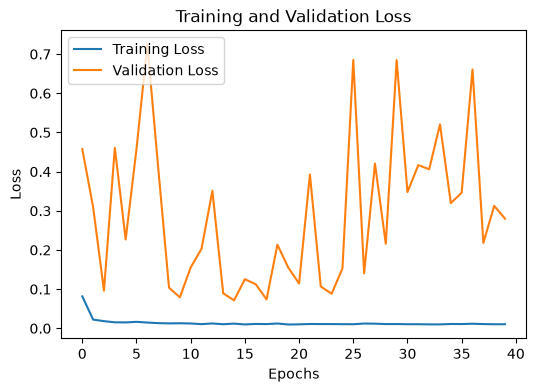

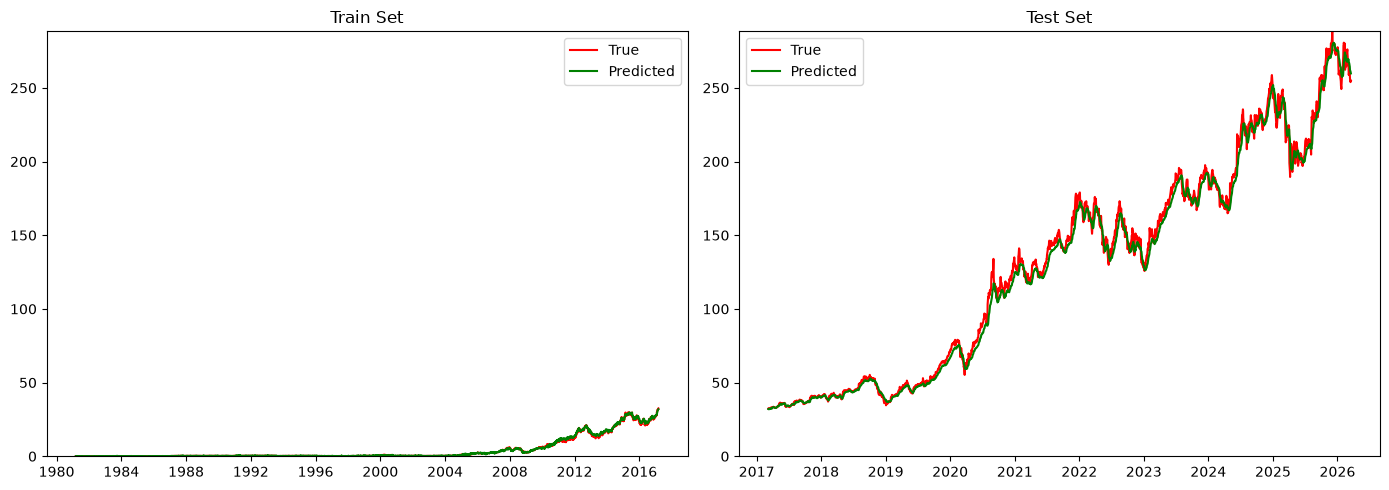

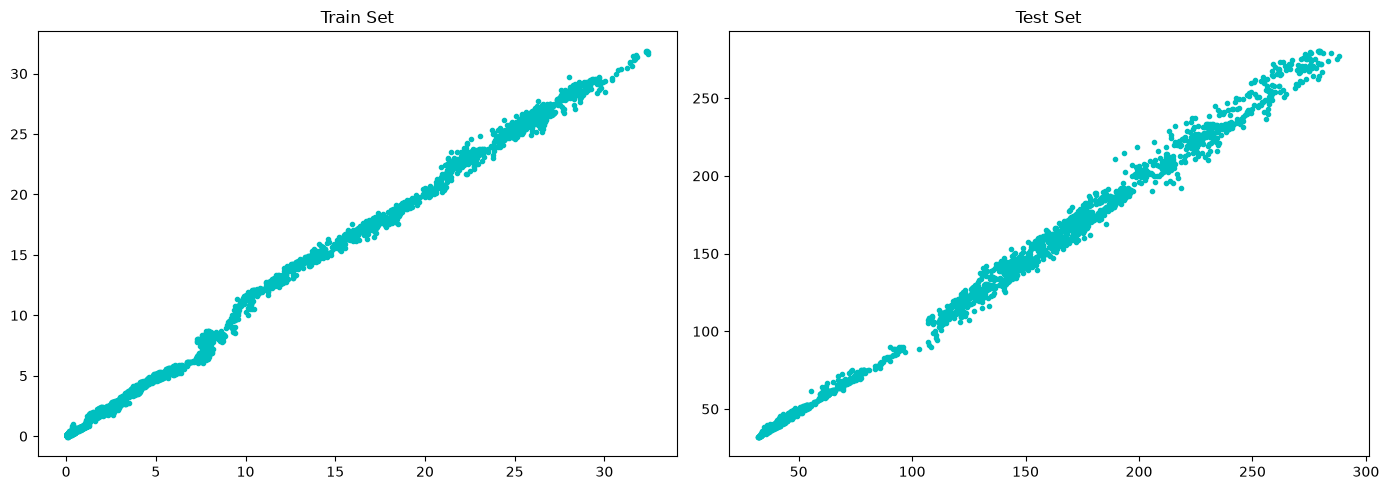

MAE:
  Train: 0.1961
  Test:  3.8768
R^2:
  Train: 0.9974
  Test:  0.9948


In [38]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# Get predictions on scaled data
y_train_pred_scaled = model_dense.predict(X_train_scaled_2d)[:,0].reshape(-1, 1)
y_test_pred_scaled  = model_dense.predict(X_test_scaled_2d)[:,0].reshape(-1, 1)

# Inverse transform predictions to original scale
y_train_pred = scaler_y.inverse_transform(y_train_pred_scaled).flatten()
y_test_pred  = scaler_y.inverse_transform(y_test_pred_scaled).flatten()

# Define true unscaled values for comparison
y_train_true = y_train
y_test_true = y_test

# Create a figure with two subplots side by side
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

# Left subplot: Training and Validation Loss
ax.plot(history_dense.history['loss'], label='Training Loss')
ax.plot(history_dense.history['val_loss'], label='Validation Loss')
ax.set_title('Training and Validation Loss')
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.legend()

r2_train = r2_score(y_train_true, y_train_pred)
print(f'r2_train:   {r2_train:.5}')

r2_test = r2_score(y_test_true, y_test_pred)
print(f'r2_test:    {r2_test:.5}')

rmse_train = mean_squared_error(y_train_true, y_train_pred)**0.5
print(f'rmse_train: {rmse_train:.5}')

rmse_test = mean_squared_error(y_test_true, y_test_pred)**0.5
print(f'rmse_test:  {rmse_test:.5}')

y_train_pred = pd.Series(y_train_pred, index=dates_train)
y_test_pred  = pd.Series(y_test_pred, index=dates_test)

# Calculate global y-axis limits
y_min = min(y_train_true.min(), y_train_pred.min(), y_test_true.min(), y_test_pred.min())
y_max = max(y_train_true.max(), y_train_pred.max(), y_test_true.max(), y_test_pred.max())

# Plot train and test side by side with shared y limits
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(dates_train, y_train_true, 'r', label='True')
axs[0].plot(y_train_pred, 'g', label='Predicted')
axs[0].set_title('Train Set')
axs[0].set_ylim(y_min, y_max)
axs[0].legend()

axs[1].plot(dates_test, y_test_true, 'r', label='True')
axs[1].plot(y_test_pred, 'g', label='Predicted')
axs[1].set_title('Test Set')
axs[1].set_ylim(y_min, y_max)
axs[1].legend()

plt.tight_layout()
plt.show()

# Plot train and test side by side with shared y limits
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(y_train_true, y_train_pred.values, 'c.')
axs[0].set_title('Train Set')
# axs[0].legend() # Removed as there's no label for scatter plot

axs[1].plot(y_test_true, y_test_pred.values, 'c.')
axs[1].set_title('Test Set')
# axs[1].legend() # Removed as there's no label for scatter plot

plt.tight_layout()
plt.show()

mae_train = mean_absolute_error(y_train_true, y_train_pred)
r2_train = r2_score(y_train_true, y_train_pred)
mae_test = mean_absolute_error(y_test_true, y_test_pred)
r2_test = r2_score(y_test_true, y_test_pred)

print("MAE:")
print(f"  Train: {mae_train:.4f}")
print(f"  Test:  {mae_test:.4f}")
print("R^2:")
print(f"  Train: {r2_train:.4f}")
print(f"  Test:  {r2_test:.4f}")

In [39]:
!mlflow ui

Backend store URI not provided. Using sqlite:///mlflow.db
Registry store URI not provided. Using backend store URI.
2026/06/18 18:52:30 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/18 18:52:30 INFO mlflow.store.db.utils: Updating database tables
[MLflow] Security middleware enabled with default settings (localhost-only). To allow connections from other hosts, use --host 0.0.0.0 and configure --allowed-hosts and --cors-allowed-origins.
/usr/local/lib/python3.12/dist-packages/mlflow/server/fastapi_app.py:17: StarletteDeprecationWarning: starlette.middleware.wsgi is deprecated and will be removed in a future release. Please refer to https://github.com/abersheeran/a2wsgi as a replacement.
  from starlette.middleware.wsgi import WSGIResponder, build_environ
2026/06/18 18:52:34 INFO:     Uvicorn running on http://127.0.0.1:5000 (Press CTRL+C to quit)
2026/06/18 18:52:34 INFO:     Started parent process [129036]
/usr/local/lib/python3.12/dist-packages/mlflow/

### Alternative: Viewing MLflow UI with `localtunnel`

Since `ngrok` requires an authenticated token, we can use `localtunnel` as an alternative. `localtunnel` can also expose your local MLflow UI to a public URL, often without requiring explicit authentication for basic use.


# LSTM

In [40]:
# Create lagged sequences
window_size = 10

#perm = np.arange(window_size)
perm = np.random.permutation(np.arange(window_size))

X_recent, y_recent = [], []
dates_recent = []
for i in range(len(stocks) - window_size):
    X_recent.append(stocks.iloc[i:i+window_size].values)
    # Predict only the 'close' price (index 1) for y
    y_recent.append(stocks.iloc[i+window_size, 1])
    dates_recent.append(stocks.index[i+window_size])

X_recent = np.array(X_recent)
y_recent = np.array(y_recent)
dates_recent = np.array(dates_recent)

print(f"X shape: {X_recent.shape}, y shape: {y_recent.shape}")

X shape: (11347, 10, 7), y shape: (11347,)


In [41]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay, PolynomialDecay
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau # new update

# define training parameters
epochs          = 500
batch_size      = 256
decay_epochs    = int( epochs * 0.5 )

n_train         = X_train_3d.shape[0]
steps_per_epoch = int( np.ceil( n_train / batch_size ) )
decay_steps     = decay_epochs * steps_per_epoch
#print(decay_steps)

# Define the learning rate schedule
initial_learning_rate = 0.05

lr_schedule_exp = ExponentialDecay(
    initial_learning_rate=initial_learning_rate,
    decay_rate=5.0,
    decay_steps=decay_steps
)

lr_schedule_poly = PolynomialDecay(
    initial_learning_rate=initial_learning_rate,
    end_learning_rate=0.001,
    decay_steps=decay_steps,
    power=1.0
)

# Define the optimizer with a custom learning rate
optimizer = Adam(
    learning_rate=initial_learning_rate,
    #learning_rate=lr_schedule_exp,
    #learning_rate=lr_schedule_poly,
    #clipnorm=1,
    #clipvalue=1,
)

# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=50,          # Stop after 5 epochs without improvement
    restore_best_weights=True  # Restore the best weights after stopping
)

# Callback to reduce LR when a monitored metric has stopped improving
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',       # metric to monitor
    factor=0.5,               # factor by which to reduce the LR
    patience=50,              # number of epochs with no improvement after which LR will be reduced
    min_lr=1e-6,              # lower bound on the learning rate
    verbose=1                 # print when LR is reduced
)

# Compile model
model.compile(
    optimizer=optimizer,
    loss='mae'
)

In [42]:
'''from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=50,          # Stop after 5 epochs without improvement
    restore_best_weights=True  # Restore the best weights after stopping
)

# Callback to reduce LR when a monitored metric has stopped improving
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',       # metric to monitor
    factor=0.5,               # factor by which to reduce the LR
    patience=50,              # number of epochs with no improvement after which LR will be reduced
    min_lr=1e-6,              # lower bound on the learning rate
    verbose=1                 # print when LR is reduced
)'''

"from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau\n\n# Early stopping callback\nearly_stopping = EarlyStopping(\n    monitor='val_loss',  # Monitor validation loss\n    patience=50,          # Stop after 5 epochs without improvement\n    restore_best_weights=True  # Restore the best weights after stopping\n)\n\n# Callback to reduce LR when a monitored metric has stopped improving\nreduce_lr = ReduceLROnPlateau(\n    monitor='val_loss',       # metric to monitor\n    factor=0.5,               # factor by which to reduce the LR\n    patience=50,              # number of epochs with no improvement after which LR will be reduced\n    min_lr=1e-6,              # lower bound on the learning rate\n    verbose=1                 # print when LR is reduced\n)"

### Cross validation for LSTM entire stock dataset with scaling

In [43]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np

# Define the LSTM model building function for cross-validation
def build_lstm_model_cv(window_size, num_features, dropout_rate=0.2, learning_rate=0.001):
    model = Sequential([
        Input(shape=(window_size, num_features)),
        LSTM(64, return_sequences=True),
        Dropout(dropout_rate),
        BatchNormalization(),
        LSTM(32, return_sequences=False),
        Dropout(dropout_rate),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mae')
    return model

# Assuming X_recent and y_recent are already defined and represent the data to be used
# X_recent has shape (n_samples, window_size, n_features)
# y_recent has shape (n_samples,)

# Define cross-validation parameters
n_splits = 5
kf_time_series = TimeSeriesSplit(n_splits=n_splits)

epochs = 150 # adjust this
batch_size = 64 # adjust this

train_mae_cv_list = []
test_mae_cv_list = []
train_r2_cv_list = []
test_r2_cv_list = []

fold = 1
# X_recent and y_recent are 3D and 1D respectively, but TimeSeriesSplit expects 2D array for X
# We will use X_recent_2d and reshape within the loop for LSTM input

# First, reshape X_recent to 2D for TimeSeriesSplit
X_recent_2d = X_recent.reshape(X_recent.shape[0], -1)

for train_index, test_index in kf_time_series.split(X_recent_2d):
    print(f"Fold {fold}/{n_splits}")

    # Split data for the current fold
    X_train_fold_2d, X_test_fold_2d = X_recent_2d[train_index], X_recent_2d[test_index]
    y_train_fold, y_test_fold = y_recent[train_index], y_recent[test_index]

    # Scale X and y within the fold to prevent data leakage
    scaler_X_cv = MinMaxScaler(feature_range=(0, 1))
    scaler_y_cv = MinMaxScaler(feature_range=(0, 1))

    X_train_scaled_2d = scaler_X_cv.fit_transform(X_train_fold_2d)
    X_test_scaled_2d = scaler_X_cv.transform(X_test_fold_2d)

    y_train_scaled = scaler_y_cv.fit_transform(y_train_fold.reshape(-1, 1))
    y_test_scaled = scaler_y_cv.transform(y_test_fold.reshape(-1, 1))

    # Reshape scaled X data to 3D for LSTM input
    current_window_size = X_recent.shape[1] # This should be 10
    current_num_features = X_recent.shape[2] # This should be 5

    X_train_scaled_3d_cv = X_train_scaled_2d.reshape((X_train_scaled_2d.shape[0], current_window_size, current_num_features))
    X_test_scaled_3d_cv = X_test_scaled_2d.reshape((X_test_scaled_2d.shape[0], current_window_size, current_num_features))

    # Build a fresh LSTM model for each fold
    model_lstm_cv = build_lstm_model_cv(current_window_size, current_num_features)

    # Early stopping callback
    early_stopping_cv = EarlyStopping(
        monitor='val_loss',
        patience=25, # Adjusted patience for cross-validation
        restore_best_weights=True
    )

    # Train the model
    history_cv = model_lstm_cv.fit(
        X_train_scaled_3d_cv, y_train_scaled,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_test_scaled_3d_cv, y_test_scaled),
        verbose=0,
        callbacks=[early_stopping_cv]
    )

    # Evaluate on training data
    y_train_pred_scaled_cv = model_lstm_cv.predict(X_train_scaled_3d_cv, verbose=0)
    y_train_pred_cv = scaler_y_cv.inverse_transform(y_train_pred_scaled_cv) # Inverse transform predictions
    train_mae_cv = mean_absolute_error(y_train_fold, y_train_pred_cv)
    train_r2_cv = r2_score(y_train_fold, y_train_pred_cv)

    # Evaluate on test data
    y_test_pred_scaled_cv = model_lstm_cv.predict(X_test_scaled_3d_cv, verbose=0)
    y_test_pred_cv = scaler_y_cv.inverse_transform(y_test_pred_scaled_cv) # Inverse transform predictions
    test_mae_cv = mean_absolute_error(y_test_fold, y_test_pred_cv)
    test_r2_cv = r2_score(y_test_fold, y_test_pred_cv)

    print("MAE:")
    print(f"  Train: {train_mae_cv:.4f}")
    print(f"  Test:  {test_mae_cv:.4f}")
    print("R^2:")
    print(f"  Train: {train_r2_cv:.4f}")
    print(f"  Test:  {test_r2_cv:.4f}")
    print()

    train_mae_cv_list.append(train_mae_cv)
    test_mae_cv_list.append(test_mae_cv)
    train_r2_cv_list.append(train_r2_cv)
    test_r2_cv_list.append(test_r2_cv)

    fold += 1
# end

print("\nCross-validation results:")
cv_results_df = pd.DataFrame({
    'Train MAE': train_mae_cv_list,
    'Test MAE': test_mae_cv_list,
    'Train R2': train_r2_cv_list,
    'Test R2': test_r2_cv_list
})
display(cv_results_df)
display(cv_results_df.describe())

Fold 1/5
MAE:
  Train: 0.0080
  Test:  0.0143
R^2:
  Train: 0.9865
  Test:  0.9377

Fold 2/5
MAE:
  Train: 0.0148
  Test:  0.0341
R^2:
  Train: 0.9746
  Test:  0.8885

Fold 3/5
MAE:
  Train: 0.0417
  Test:  2.6371
R^2:
  Train: 0.8859
  Test:  -0.9469

Fold 4/5
MAE:
  Train: 0.1346
  Test:  12.6012
R^2:
  Train: 0.9749
  Test:  -1.5992

Fold 5/5
MAE:
  Train: 1.0933
  Test:  87.7024
R^2:
  Train: 0.9450
  Test:  -1.7279


Cross-validation results:


,Train MAE,Test MAE,Train R2,Test R2
0,0.007953,0.014252,0.986459,0.937654
1,0.014841,0.034119,0.974592,0.888481
2,0.041726,2.637098,0.885891,-0.946911
3,0.134614,12.601237,0.974932,-1.599238
4,1.093265,87.702372,0.944953,-1.727897


,Train MAE,Test MAE,Train R2,Test R2
count,5.000000,5.000000,5.000000,5.000000
mean,0.258480,20.597816,0.953366,-0.489582
std,0.469392,37.868532,0.040726,1.314341
min,0.007953,0.014252,0.885891,-1.727897
25%,0.014841,0.034119,0.944953,-1.599238
50%,0.041726,2.637098,0.974592,-0.946911
75%,0.134614,12.601237,0.974932,0.888481
max,1.093265,87.702372,0.986459,0.937654


In [44]:
num_features = X_train_3d.shape[2]

model_lstm = Sequential([
    Input(shape=(window_size, num_features)),

    LSTM(64, return_sequences=True),
    Dropout(0.2),
    BatchNormalization(),

    LSTM(32, return_sequences=False),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dense(1)
])

# Define the optimizer with a custom learning rate
optimizer = Adam(learning_rate=0.001)

# Compile model
model_lstm.compile(
    optimizer=optimizer,
    loss='mae',
)

# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=25,          # Stop after 25 epochs without improvement
    restore_best_weights=True  # Restore the best weights after stopping
)

model_lstm.summary()

# Re-scale y_train and y_test using the original scaler_y from the initial split
y_train_scaled = scaler_y.transform(y_train.reshape(-1,1))
y_test_scaled  = scaler_y.transform(y_test.reshape(-1,1))

# Train the LSTM model with the correctly scaled data from the initial 80/20 split
history_lstm = model_lstm.fit(
    X_train_scaled_3d, y_train_scaled,
    epochs=150,
    batch_size=64,
    validation_data=(X_test_scaled_3d, y_test_scaled),
    verbose=1,
    callbacks=[early_stopping]
)

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_10 (LSTM)                  │ (None, 10, 64)         │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 10, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,193 (125.75 KB)

 Trainable params: 32,065 (125.25 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0440 - val_loss: 2.0522
Epoch 2/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0176 - val_loss: 1.9549
Epoch 3/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0119 - val_loss: 1.9428
Epoch 4/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0105 - val_loss: 1.9519
Epoch 5/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0097 - val_loss: 1.7898
Epoch 6/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0089 - val_loss: 1.8876
Epoch 7/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0083 - val_loss: 1.9349
Epoch 8/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0083 - val_loss: 1.8943
Epoch 9/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0077 - val_loss: 1.9056
Epoch 10/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0075 - val_loss: 1.8280
Epoch 11/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0069 - val_loss: 1.7586
Epoch 12/150
142/142 ━━━━━━━━━━━━━━━━━━━━

In [45]:
'''history_lstm = model_lstm.fit(
    X_train_scaled_3d, y_train_scaled, # Use scaled 3D data
    epochs=150,
    batch_size=64,
    validation_data=(X_test_scaled_3d, y_test_scaled), # Use scaled 3D data for validation
    verbose=1,
    callbacks=[early_stopping]
)'''

'history_lstm = model_lstm.fit(\n    X_train_scaled_3d, y_train_scaled, # Use scaled 3D data\n    epochs=150,\n    batch_size=64,\n    validation_data=(X_test_scaled_3d, y_test_scaled), # Use scaled 3D data for validation\n    verbose=1,\n    callbacks=[early_stopping]\n)'

284/284 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


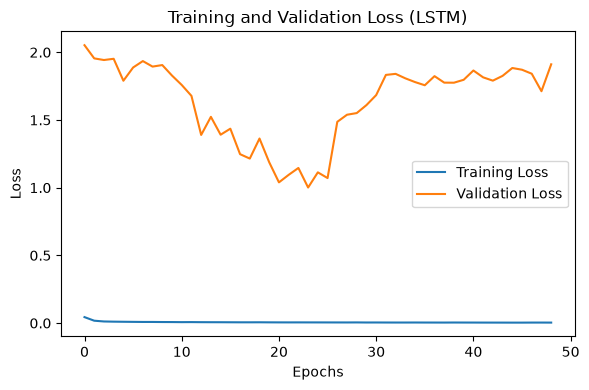

r2_train:   0.96743
r2_test:    0.0078508
rmse_train: 1.3603
rmse_test:  72.329


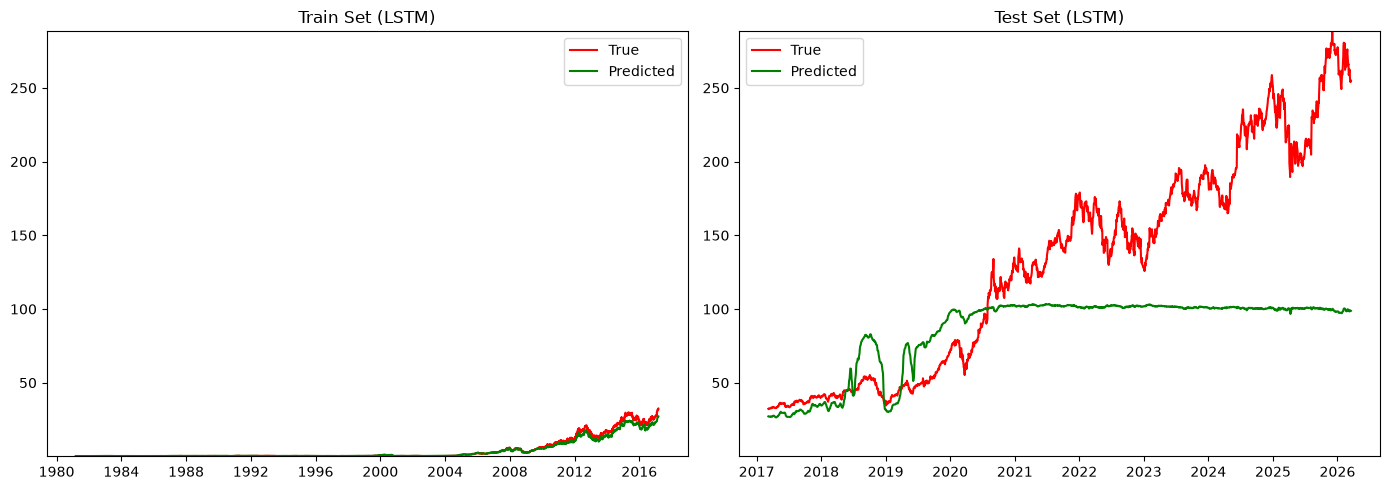

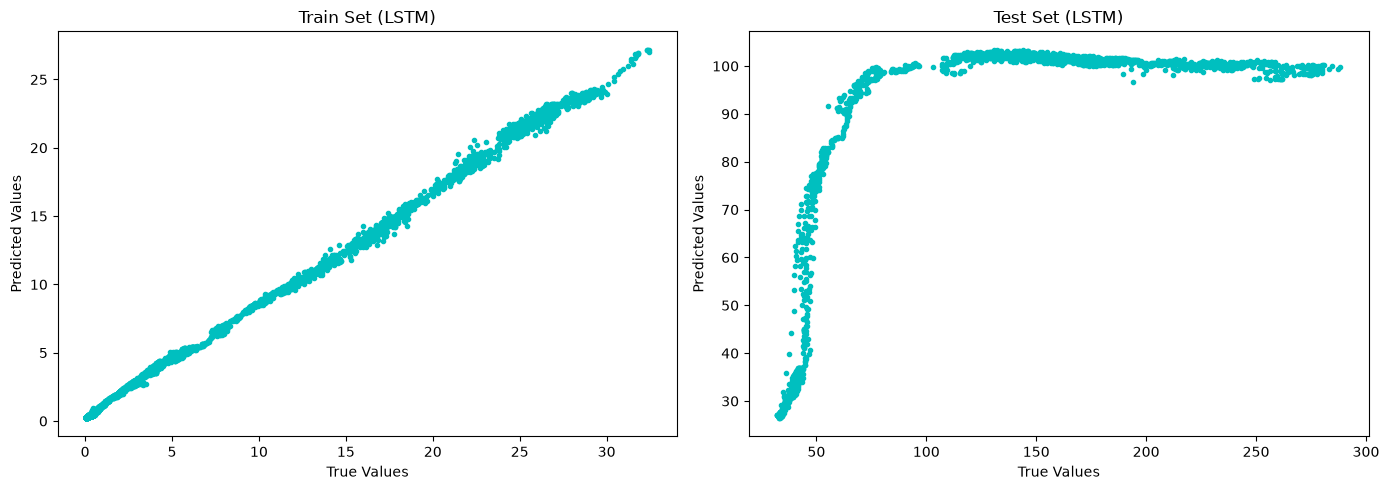

MAE:
  Train: 0.6696
  Test:  54.3784
R^2:
  Train: 0.9674
  Test:  0.0079


In [46]:
# Get predictions on scaled data
y_train_pred_scaled = model_lstm.predict(X_train_scaled_3d)[:,0].reshape(-1, 1)
y_test_pred_scaled  = model_lstm.predict(X_test_scaled_3d)[:,0].reshape(-1, 1)

# Inverse transform predictions to original scale
y_train_pred = scaler_y.inverse_transform(y_train_pred_scaled).flatten()
y_test_pred  = scaler_y.inverse_transform(y_test_pred_scaled).flatten()

# Now use the true values and dates from the train_test_split
y_train_true = y_train
y_test_true = y_test
dates_train_plot = dates_train
dates_test_plot = dates_test

# Create a figure with one subplot for loss
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

# Plot Training and Validation Loss
ax.plot(history_lstm.history['loss'], label='Training Loss')
ax.plot(history_lstm.history['val_loss'], label='Validation Loss')
ax.set_title('Training and Validation Loss (LSTM)')
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.legend()
plt.tight_layout()
plt.show()

# Calculate metrics for LSTM model
r2_train = r2_score(y_train_true, y_train_pred)
print(f'r2_train:   {r2_train:.5}')

r2_test = r2_score(y_test_true, y_test_pred)
print(f'r2_test:    {r2_test:.5}')

rmse_train = mean_squared_error(y_train_true, y_train_pred)**0.5
print(f'rmse_train: {rmse_train:.5}')

rmse_test = mean_squared_error(y_test_true, y_test_pred)**0.5
print(f'rmse_test:  {rmse_test:.5}')

# Convert predictions to pandas Series with dates as index for plotting
y_train_pred_series = pd.Series(y_train_pred.flatten(), index=dates_train_plot)
y_test_pred_series  = pd.Series(y_test_pred.flatten(), index=dates_test_plot)

# Calculate global y-axis limits for consistent plotting
y_min = min(y_train_true.min(), y_train_pred_series.min(), y_test_true.min(), y_test_pred_series.min())
y_max = max(y_train_true.max(), y_train_pred_series.max(), y_test_true.max(), y_test_pred_series.max())

# Plot train and test side by side with shared y limits
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(dates_train_plot, y_train_true, 'r', label='True')
axs[0].plot(y_train_pred_series, 'g', label='Predicted')
axs[0].set_title('Train Set (LSTM)')
axs[0].set_ylim(y_min, y_max)
axs[0].legend()

axs[1].plot(dates_test_plot, y_test_true, 'r', label='True')
axs[1].plot(y_test_pred_series, 'g', label='Predicted')
axs[1].set_title('Test Set (LSTM)')
axs[1].set_ylim(y_min, y_max)
axs[1].legend()

plt.tight_layout()
plt.show()

# Plot scatter plots for train and test side by side with shared y limits
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(y_train_true, y_train_pred_series.values, 'c.')
axs[0].set_title('Train Set (LSTM)')
axs[0].set_xlabel('True Values')
axs[0].set_ylabel('Predicted Values')
# axs[0].legend() # Removed as there's no label for scatter plot

axs[1].plot(y_test_true, y_test_pred_series.values, 'c.')
axs[1].set_title('Test Set (LSTM)')
axs[1].set_xlabel('True Values')
axs[1].set_ylabel('Predicted Values')
# axs[1].legend() # Removed as there's no label for scatter plot

plt.tight_layout()
plt.show()

mae_train = mean_absolute_error(y_train_true, y_train_pred)
mae_test = mean_absolute_error(y_test_true, y_test_pred)

print("MAE:")
print(f"  Train: {mae_train:.4f}")
print(f"  Test:  {mae_test:.4f}")
print("R^2:")
print(f"  Train: {r2_train:.4f}")
print(f"  Test:  {r2_test:.4f}")

the negative R² scores is a direct consequence of the model struggling with the non-stationary nature of stock prices over the extreme range present in the dataset (1980 to 2026).

#Gemini Suggestion and my fix

### Scaling Data for LSTM Training

The previous LSTM model was trained on unscaled data. It's crucial for neural networks like LSTMs to train on scaled data for better convergence and performance. We will now apply `MinMaxScaler` to the training and testing sets of `X` and `y` that were derived from the feature-selected data (`X_pars`).

The `scaler_X_final` will be fitted on the 2D `X_train` (before reshaping to 3D for LSTM) and `scaler_y_final` will be fitted on `y_train`. These scalers will then be used to transform both the training and testing sets.

*********************************************
### If it doesnt work run lstm in new notebook
*********************************************

Suggest to use a rolling wondow training to predict stock based on a 6 month window (windowssize = 10 days) .tail(180) or window size = 180. Train on the window and predict the next day.week. Retrain to incorporatee new actual data point.

For cross validation, fold with high R square correlates with stationarity mwanwhilee financial market are non stationary, low volatility, less noise. If i select aa performance in low volatility stationary period I am essentially training a fair weather nnodel that perform well when the mareet is quiet. Use multiple fold or regime detection to determine if current market is currently sationary or regime-shifting.

Use streess testing (isolate folds with low R square) and use as stress test set. If model can be improved to maintaainn even modest R square during ow volatilituy folds it will be significantly more robust than a modl that use only high R scores

In [47]:
recent_stocks = stocks.tail(574)
recent_stocks

,Open,High,Low,Close,Volume,Moving_Average,RSI
Date,,,,,,,
2023-12-01,188.373065,189.590414,187.284369,189.273712,45704800,177.446822,67.053646
2023-12-04,188.026663,188.095951,185.522677,187.482315,43389500,177.741163,61.115171
2023-12-05,188.254333,192.401240,188.224627,191.431320,66628400,178.088983,67.841875
2023-12-06,192.450710,192.757521,190.134773,190.342621,41089700,178.496475,64.543803
2023-12-07,191.639164,192.995073,191.599567,192.272583,47477700,178.972812,67.540913
...,...,...,...,...,...,...,...
2026-03-12,258.660004,258.950012,254.179993,255.759995,40794000,263.034650,40.400334
2026-03-13,255.479996,256.329987,249.520004,250.119995,36930000,262.580556,35.468931
2026-03-16,252.110001,253.889999,249.880005,252.820007,32074200,262.204839,39.271095


In [48]:
# Create lagged sequences
window_size = 10

#perm = np.arange(window_size)
perm = np.random.permutation(np.arange(window_size))

X_recent, y_recent = [], []
dates_recent = []
for i in range(len(recent_stocks) - window_size):
    X_recent.append(recent_stocks.iloc[i:i+window_size].values)
    # Predict only the 'close' price (index 1) for y
    y_recent.append(recent_stocks.iloc[i+window_size, 1])
    dates_recent.append(recent_stocks.index[i+window_size])

X_recent = np.array(X_recent)
y_recent = np.array(y_recent)
dates_recent = np.array(dates_recent)

print(f"X shape: {X_recent.shape}, y shape: {y_recent.shape}")

X shape: (564, 10, 7), y shape: (564,)


### Time Series Cross-Validation for LSTM Model Scaled Data

This provide a more robust evaluation of the model's performance across different time periods, similar to how other models were evaluated.

In [49]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np

# Define the LSTM model building function for cross-validation
def build_lstm_model_cv(window_size, num_features, dropout_rate=0.2, learning_rate=0.001):
    model = Sequential([
        Input(shape=(window_size, num_features)),
        LSTM(64, return_sequences=True),
        Dropout(dropout_rate),
        BatchNormalization(),
        LSTM(32, return_sequences=False),
        Dropout(dropout_rate),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mae')
    return model

# Assuming X_recent and y_recent are already defined and represent the data to be used
# X_recent has shape (n_samples, window_size, n_features)
# y_recent has shape (n_samples,)

# Define cross-validation parameters
n_splits = 5
kf_time_series = TimeSeriesSplit(n_splits=n_splits)

epochs = 150 # adjust this
batch_size = 64 # adjust this

train_mae_cv_list = []
test_mae_cv_list = []
train_r2_cv_list = []
test_r2_cv_list = []

fold = 1
# X_recent and y_recent are 3D and 1D respectively, but TimeSeriesSplit expects 2D array for X
# We will use X_recent_2d and reshape within the loop for LSTM input

# First, reshape X_recent to 2D for TimeSeriesSplit
X_recent_2d = X_recent.reshape(X_recent.shape[0], -1)

for train_index, test_index in kf_time_series.split(X_recent_2d):
    print(f"Fold {fold}/{n_splits}")

    # Split data for the current fold
    X_train_fold_2d, X_test_fold_2d = X_recent_2d[train_index], X_recent_2d[test_index]
    y_train_fold, y_test_fold = y_recent[train_index], y_recent[test_index]

    # Scale X and y within the fold to prevent data leakage
    scaler_X_cv = MinMaxScaler(feature_range=(0, 1))
    scaler_y_cv = MinMaxScaler(feature_range=(0, 1))

    X_train_scaled_2d = scaler_X_cv.fit_transform(X_train_fold_2d)
    X_test_scaled_2d = scaler_X_cv.transform(X_test_fold_2d)

    y_train_scaled = scaler_y_cv.fit_transform(y_train_fold.reshape(-1, 1))
    y_test_scaled = scaler_y_cv.transform(y_test_fold.reshape(-1, 1))

    # Reshape scaled X data to 3D for LSTM input
    current_window_size = X_recent.shape[1] # This should be 10
    current_num_features = X_recent.shape[2] # This should be 5

    X_train_scaled_3d_cv = X_train_scaled_2d.reshape((X_train_scaled_2d.shape[0], current_window_size, current_num_features))
    X_test_scaled_3d_cv = X_test_scaled_2d.reshape((X_test_scaled_2d.shape[0], current_window_size, current_num_features))

    # Build a fresh LSTM model for each fold
    model_lstm_cv = build_lstm_model_cv(current_window_size, current_num_features)

    # Early stopping callback
    early_stopping_cv = EarlyStopping(
        monitor='val_loss',
        patience=25, # Adjusted patience for cross-validation
        restore_best_weights=True
    )

    # Train the model
    history_cv = model_lstm_cv.fit(
        X_train_scaled_3d_cv, y_train_scaled,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_test_scaled_3d_cv, y_test_scaled),
        verbose=0,
        callbacks=[early_stopping_cv]
    )

    # Evaluate on training data
    y_train_pred_scaled_cv = model_lstm_cv.predict(X_train_scaled_3d_cv, verbose=0)
    y_train_pred_cv = scaler_y_cv.inverse_transform(y_train_pred_scaled_cv) # Inverse transform predictions
    train_mae_cv = mean_absolute_error(y_train_fold, y_train_pred_cv)
    train_r2_cv = r2_score(y_train_fold, y_train_pred_cv)

    # Evaluate on test data
    y_test_pred_scaled_cv = model_lstm_cv.predict(X_test_scaled_3d_cv, verbose=0)
    y_test_pred_cv = scaler_y_cv.inverse_transform(y_test_pred_scaled_cv) # Inverse transform predictions
    test_mae_cv = mean_absolute_error(y_test_fold, y_test_pred_cv)
    test_r2_cv = r2_score(y_test_fold, y_test_pred_cv)

    print("MAE:")
    print(f"  Train: {train_mae_cv:.4f}")
    print(f"  Test:  {test_mae_cv:.4f}")
    print("R^2:")
    print(f"  Train: {train_r2_cv:.4f}")
    print(f"  Test:  {test_r2_cv:.4f}")
    print()

    train_mae_cv_list.append(train_mae_cv)
    test_mae_cv_list.append(test_mae_cv)
    train_r2_cv_list.append(train_r2_cv)
    test_r2_cv_list.append(test_r2_cv)

    fold += 1
# end

print("\nCross-validation results:")
cv_results_df = pd.DataFrame({
    'Train MAE': train_mae_cv_list,
    'Test MAE': test_mae_cv_list,
    'Train R2': train_r2_cv_list,
    'Test R2': test_r2_cv_list
})
display(cv_results_df)
display(cv_results_df.describe())

Fold 1/5
MAE:
  Train: 2.8338
  Test:  22.1305
R^2:
  Train: 0.8380
  Test:  -1.3334

Fold 2/5
MAE:
  Train: 12.8087
  Test:  34.8558
R^2:
  Train: 0.3532
  Test:  -11.8942

Fold 3/5
MAE:
  Train: 5.4670
  Test:  6.2813
R^2:
  Train: 0.9268
  Test:  0.7589

Fold 4/5
MAE:
  Train: 4.1352
  Test:  7.5669
R^2:
  Train: 0.9504
  Test:  0.8067

Fold 5/5
MAE:
  Train: 3.0565
  Test:  4.6671
R^2:
  Train: 0.9721
  Test:  0.6131


Cross-validation results:


,Train MAE,Test MAE,Train R2,Test R2
0,2.833841,22.130538,0.837961,-1.333378
1,12.808681,34.855808,0.353209,-11.894192
2,5.466950,6.281271,0.926797,0.758859
3,4.135227,7.566923,0.950410,0.806705
4,3.056509,4.667120,0.972098,0.613083


,Train MAE,Test MAE,Train R2,Test R2
count,5.000000,5.000000,5.000000,5.000000
mean,5.660242,15.100332,0.808095,-2.209785
std,4.130108,13.067925,0.259352,5.487177
min,2.833841,4.667120,0.353209,-11.894192
25%,3.056509,6.281271,0.837961,-1.333378
50%,4.135227,7.566923,0.926797,0.613083
75%,5.466950,22.130538,0.950410,0.758859
max,12.808681,34.855808,0.972098,0.806705


### Defining training parameter

In [50]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay, PolynomialDecay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Input

# define training parameters
epochs          = 250
batch_size      = 256
decay_epochs    = int( epochs * 0.5 )

n_train         = X_train_3d.shape[0]
steps_per_epoch = int( np.ceil( n_train / batch_size ) )
decay_steps     = decay_epochs * steps_per_epoch
#print(decay_steps)

# Define the learning rate schedule
initial_learning_rate = 0.001 # Changed from 0.05 to 0.001 to match CV setup

lr_schedule_exp = ExponentialDecay(
    initial_learning_rate=initial_learning_rate,
    decay_rate=5.0,
    decay_steps=decay_steps
)

lr_schedule_poly = PolynomialDecay(
    initial_learning_rate=initial_learning_rate,
    end_learning_rate=0.001,
    decay_steps=decay_steps,
    power=1.0
)

# Define model_lstm_final (moved from a later cell)
window_size = 10 # Assuming this is consistent
num_features = X_train_3d.shape[2] # Corrected: Derive num_features from the actual number of features

model_lstm_final = Sequential([
    Input(shape=(window_size, num_features)),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    BatchNormalization(),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

# Define the optimizer with a custom learning rate
optimizer = Adam(
    learning_rate=initial_learning_rate,
    #learning_rate=lr_schedule_exp,
    #learning_rate=lr_schedule_poly,
    #clipnorm=1,
    #clipvalue=1,
)

# Compile model
model_lstm_final.compile(
    optimizer=optimizer,
    loss='mae'
)

### Retraining LSTM Model with Scaled Data

Now we will define and retrain the LSTM model using the newly scaled `X_train_scaled_3d` and `y_train_scaled` data. We will use the same architecture and early stopping mechanism as before. After training, we will evaluate its performance.

In [51]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.preprocessing import MinMaxScaler # Import MinMaxScaler

# Correctly determine the number of features from the scaled 3D data
num_features = X_train_scaled_3d_cv.shape[2]

# Define the LSTM model with the same architecture as before
model_lstm_final = Sequential([
    Input(shape=(window_size, num_features)), # Use the correctly calculated num_features

    LSTM(64, return_sequences=True),
    Dropout(0.2),
    BatchNormalization(),

    LSTM(32, return_sequences=False),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dense(1)
])

# Define the optimizer and compile the model
optimizer = Adam(learning_rate=0.001) # Use the same learning rate as previous LSTM
model_lstm_final.compile(
    optimizer=optimizer,
    loss='mae',
)

# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=25,          # Stop after 25 epochs without improvement (consistent with previous)
    restore_best_weights=True  # Restore the best weights after stopping
)

model_lstm_final.summary()

# --- Start of added check for data cardinality ---
#print(f"Checking X_train_scaled_3d shape: {X_train_scaled_3d_cv.shape}")
#print(f"Checking y_train_scaled shape: {y_train_scaled.shape}")

#if X_train_scaled_3d.shape[0] != y_train_scaled.shape[0]:
#    raise ValueError(f"Data cardinality mismatch: X_train has {X_train_scaled_3d.shape[0]} samples, but y_train has {y_train_scaled.shape[0]} samples.")
# --- End of added check for data cardinality ---

# Initialize and fit scaler_y_final with the unscaled y_train_fold from the last CV fold
scaler_y_final = MinMaxScaler(feature_range=(0, 1))
scaler_y_final.fit(y_train_fold.reshape(-1, 1))

# Train the model with scaled data
history_lstm_final = model_lstm_final.fit(
    X_train_scaled_3d_cv, y_train_scaled,
    epochs=250, # Use same number of epochs
    batch_size=64, # Reverting batch size as per user's preference
    validation_data=(X_test_scaled_3d_cv, y_test_scaled),
    verbose=1,
    callbacks=[early_stopping]
)

# Get predictions using the final model
y_train_pred_scaled = model_lstm_final.predict(X_train_scaled_3d_cv)
y_test_pred_scaled  = model_lstm_final.predict(X_test_scaled_3d_cv)

# Inverse transform predictions to original scale
y_train_pred = scaler_y_final.inverse_transform(y_train_pred_scaled)
y_test_pred  = scaler_y_final.inverse_transform(y_test_pred_scaled)

# Inverse transform true values for consistent comparison based on the cv fold
y_train_true_original = y_train_fold
y_test_true_original = y_test_fold

# Calculate metrics for the retrained LSTM model
r2_train = r2_score(y_train_true_original, y_train_pred)
print(f'r2_train:   {r2_train:.5}')

r2_test = r2_score(y_test_true_original, y_test_pred)
print(f'r2_test:    {r2_test:.5}')

rmse_train = mean_squared_error(y_train_true_original, y_train_pred)**0.5
print(f'rmse_train: {rmse_train:.5}')

rmse_test = mean_squared_error(y_test_true_original, y_test_pred)**0.5
print(f'rmse_test:  {rmse_test:.5}')

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_24 (LSTM)                  │ (None, 10, 64)         │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 10, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_25 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_37 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,193 (125.75 KB)

 Trainable params: 32,065 (125.25 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.3476 - val_loss: 0.6380
Epoch 2/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1923 - val_loss: 0.6472
Epoch 3/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1559 - val_loss: 0.5720
Epoch 4/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1353 - val_loss: 0.6192
Epoch 5/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1121 - val_loss: 0.5716
Epoch 6/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1086 - val_loss: 0.5996
Epoch 7/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1017 - val_loss: 0.5819
Epoch 8/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0989 - val_loss: 0.5754
Epoch 9/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0902 - val_loss: 0.5660
Epoch 10/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0901 - val_loss: 0.5909
Epoch 11/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0897 - val_loss: 0.5347
Epoch 12/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0800 - val_lo

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


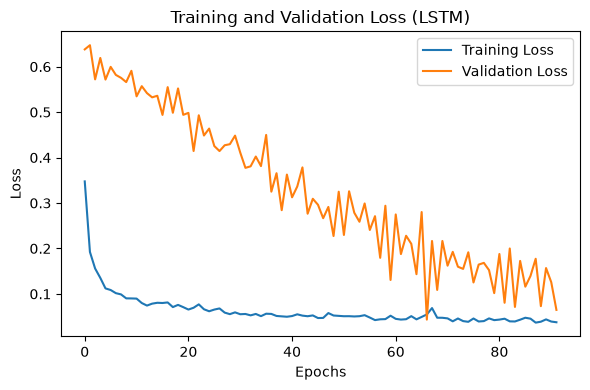

r2_train:   0.94818
r2_test:    0.601
rmse_train: 5.649
rmse_test:  5.5899


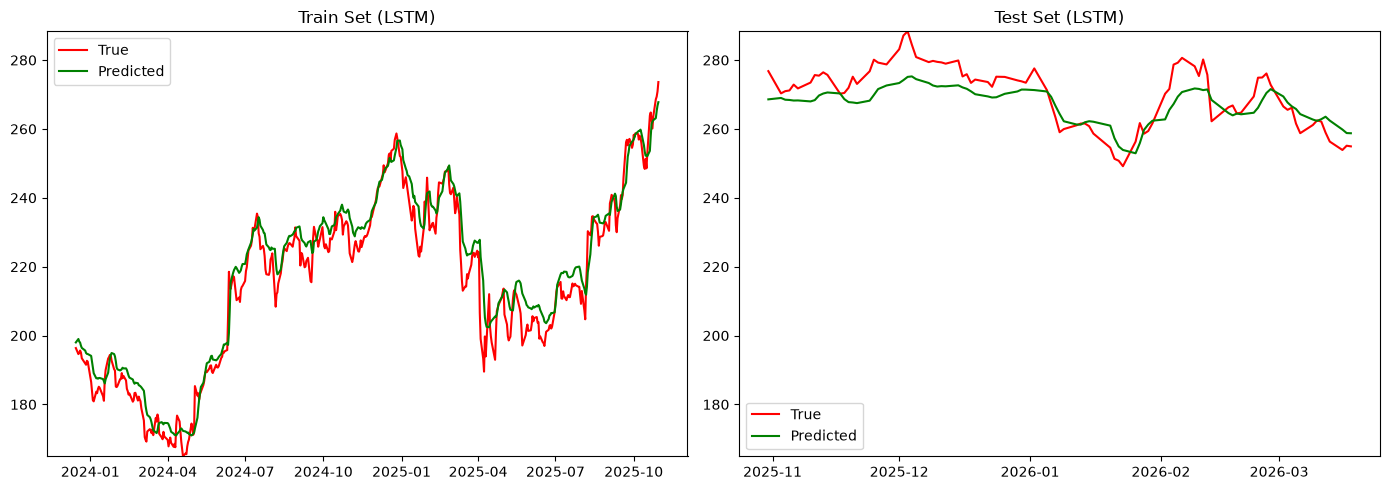

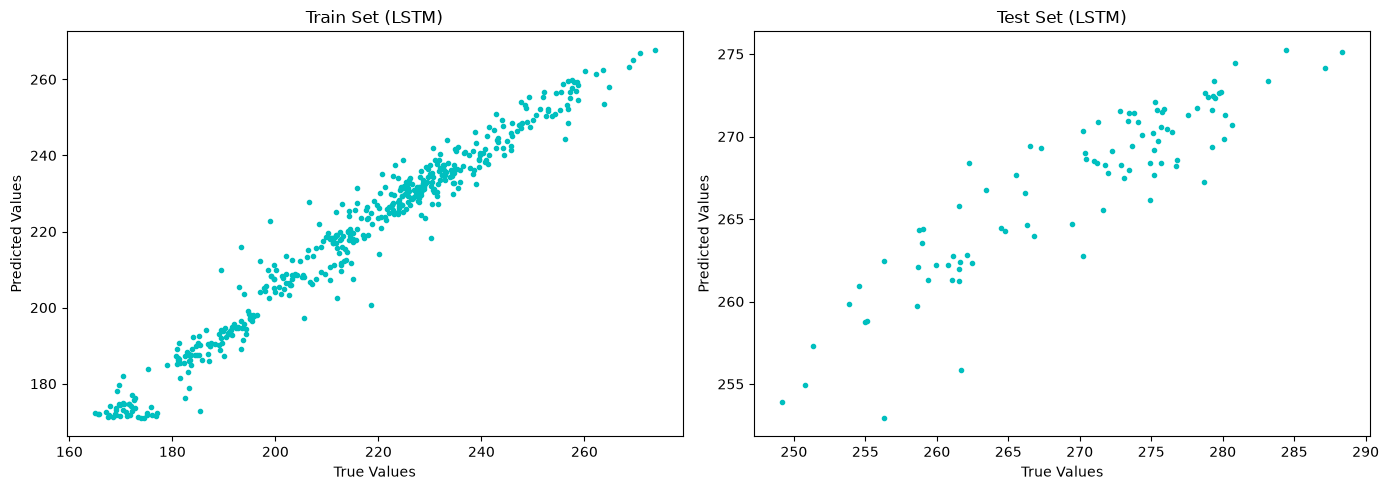

MAE:
  Train: 4.4191
  Test:  4.7292
R^2:
  Train: 0.9482
  Test:  0.6010


In [52]:
n_splits = 5 # Assuming n_splits is 5 as used in previous CV
kf_time_series_reget = TimeSeriesSplit(n_splits=n_splits)

last_train_index = None
last_test_index = None
last_y_train_fold = None
last_y_test_fold = None
last_scaler_y_cv = None

# Iterate through the splits to get the data and scaler for the last fold
# X_recent_2d is assumed to be available from prior cells.
for i, (tr_idx, ts_idx) in enumerate(kf_time_series_reget.split(X_recent_2d)):
    if i == n_splits - 1: # This is the last fold which is fold 5
        last_train_index = tr_idx
        last_test_index = ts_idx
        last_y_train_fold = y_recent[tr_idx]
        last_y_test_fold = y_recent[ts_idx]

        # Recreate scaler_y_cv for the last fold to ensure consistency
        temp_scaler_y_cv = MinMaxScaler(feature_range=(0,1))
        temp_scaler_y_cv.fit(last_y_train_fold.reshape(-1, 1))
        last_scaler_y_cv = temp_scaler_y_cv
        break


y_train_pred_scaled = model_lstm_final.predict(X_train_scaled_3d_cv)
y_test_pred_scaled  = model_lstm_final.predict(X_test_scaled_3d_cv)

# Inverse transform predictions to original scale using the correct scaler_y_cv
y_train_pred = last_scaler_y_cv.inverse_transform(y_train_pred_scaled)
y_test_pred  = last_scaler_y_cv.inverse_transform(y_test_pred_scaled)

# Now use the true values and dates from the last fold's split
y_train_true = last_y_train_fold.reshape(-1, 1)
y_test_true = last_y_test_fold.reshape(-1, 1)
dates_train_plot = dates_recent[last_train_index]
dates_test_plot = dates_recent[last_test_index]

# Create a figure with one subplot for loss
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

# Plot Training and Validation Loss
ax.plot(history_lstm_final.history['loss'], label='Training Loss')
ax.plot(history_lstm_final.history['val_loss'], label='Validation Loss')
ax.set_title('Training and Validation Loss (LSTM)')
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.legend()
plt.tight_layout()
plt.show()

# Calculate metrics for LSTM model
r2_train = r2_score(y_train_true, y_train_pred)
print(f'r2_train:   {r2_train:.5}')

r2_test = r2_score(y_test_true, y_test_pred)
print(f'r2_test:    {r2_test:.5}')

rmse_train = mean_squared_error(y_train_true, y_train_pred)**0.5
print(f'rmse_train: {rmse_train:.5}')

rmse_test = mean_squared_error(y_test_true, y_test_pred)**0.5
print(f'rmse_test:  {rmse_test:.5}')

# Convert predictions to pandas Series with dates as index for plotting
y_train_pred_series = pd.Series(y_train_pred.flatten(), index=dates_train_plot)
y_test_pred_series  = pd.Series(y_test_pred.flatten(), index=dates_test_plot)

# Calculate global y-axis limits for consistent plotting
y_min = min(y_train_true.min(), y_train_pred_series.min(), y_test_true.min(), y_test_pred_series.min())
y_max = max(y_train_true.max(), y_train_pred_series.max(), y_test_true.max(), y_test_pred_series.max())

# Plot train and test side by side with shared y limits
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(dates_train_plot, y_train_true, 'r', label='True')
axs[0].plot(y_train_pred_series, 'g', label='Predicted')
axs[0].set_title('Train Set (LSTM)')
axs[0].set_ylim(y_min, y_max)
axs[0].legend()

axs[1].plot(dates_test_plot, y_test_true, 'r', label='True')
axs[1].plot(y_test_pred_series, 'g', label='Predicted')
axs[1].set_title('Test Set (LSTM)')
axs[1].set_ylim(y_min, y_max)
axs[1].legend()

plt.tight_layout()
plt.show()

# Plot scatter plots for train and test side by side with shared y limits
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(y_train_true, y_train_pred_series.values, 'c.')
axs[0].set_title('Train Set (LSTM)')
axs[0].set_xlabel('True Values')
axs[0].set_ylabel('Predicted Values')
# axs[0].legend() # Removed as there's no label for scatter plot

axs[1].plot(y_test_true, y_test_pred_series.values, 'c.')
axs[1].set_title('Test Set (LSTM)')
axs[1].set_xlabel('True Values')
axs[1].set_ylabel('Predicted Values')
# axs[1].legend() # Removed as there's no label for scatter plot

plt.tight_layout()
plt.show()

mae_train = mean_absolute_error(y_train_true, y_train_pred)
mae_test = mean_absolute_error(y_test_true, y_test_pred)

print("MAE:")
print(f"  Train: {mae_train:.4f}")
print(f"  Test:  {mae_test:.4f}")
print("R^2:")
print(f"  Train: {r2_train:.4f}")
print(f"  Test:  {r2_test:.4f}")

In [53]:
# Create a DataFrame to organize the data of true vs pred data graph
predicted_results_df_corrected = pd.DataFrame({
    'Actual Close Price': pd.Series(y_test_true.flatten(), index=dates_test_plot), # Use y_test_true and dates_test_plot
    'Predicted Stock Price': pd.Series(y_test_pred.flatten(), index=dates_test_plot),
    'Difference (Error)': (pd.Series(y_test_true.flatten(), index=dates_test_plot) - pd.Series(y_test_pred.flatten(), index=dates_test_plot)),
    'Percentage Error (%)': ((abs(pd.Series(y_test_true.flatten(), index=dates_test_plot) - pd.Series(y_test_pred.flatten(), index=dates_test_plot))) / pd.Series(y_test_true.flatten(), index=dates_test_plot)) * 100
})

# Get the original 'Open' prices from the stocks DataFrame using dates_test_plot's index
# Note: 'stocks' DataFrame has 'Open' (capital O) column
open_prices = stocks.loc[dates_test_plot, ['Open']]

# Merge this information into predicted_results_df, aligning by index
predicted_results_df_corrected = predicted_results_df_corrected.merge(open_prices, left_index=True, right_index=True)

# Reorder columns for clarity, putting 'Open' and 'Actual Close Price' first
predicted_results_df_corrected = predicted_results_df_corrected[[
    'Open', 'Actual Close Price', 'Predicted Stock Price',
    'Difference (Error)', 'Percentage Error (%)'
]]

# Sort the DataFrame by its index (dates) to enable proper time-series slicing
predicted_results_df_corrected = predicted_results_df_corrected.sort_index()

# Display the corrected numerical table filtered from 2007 to 2026
display(predicted_results_df_corrected.loc['2025':'2026'])

,Open,Actual Close Price,Predicted Stock Price,Difference (Error),Percentage Error (%)
2025-10-31,276.463053,276.792443,268.594482,8.197960,2.961772
2025-11-03,269.905566,270.334741,268.995880,1.338861,0.495260
2025-11-04,267.819507,270.973499,268.490295,2.483203,0.916401
2025-11-05,268.098980,271.183128,268.417023,2.766106,1.020014
2025-11-06,267.380377,272.879874,268.252838,4.627036,1.695631
...,...,...,...,...,...
2026-03-12,258.660004,258.950012,263.556641,-4.606628,1.778964
2026-03-13,255.479996,256.329987,262.428131,-6.098145,2.379021
2026-03-16,252.110001,253.889999,259.824768,-5.934769,2.337535
2026-03-17,252.960007,255.130005,258.803925,-3.673920,1.440019


### Saving the Trained Model and Scalers
Save the retrained LSTM model (`lstm_model.keras`), the fitted X-scaler (`scaler_X.pkl`), and the fitted y-scaler (`scaler_y.pkl`) to project directory. These files can be loaded later to make new predictions without retraining or re-fitting the scalers. This uses the last fold (fold 5) of the cross validation

In [54]:
'''# Save the LSTM model
model_lstm_final.save('lstm_model.keras')
print("LSTM model saved as 'lstm_model.keras'")

# Save the X scaler
joblib.dump(scaler_X_final, 'scaler_X.pkl')
print("X scaler saved as 'scaler_X.pkl'")

# Save the y scaler
joblib.dump(scaler_y_final, 'scaler_y.pkl')
print("Y scaler saved as 'scaler_y.pkl'")'''

'# Save the LSTM model\nmodel_lstm_final.save(\'lstm_model.keras\')\nprint("LSTM model saved as \'lstm_model.keras\'")\n\n# Save the X scaler\njoblib.dump(scaler_X_final, \'scaler_X.pkl\')\nprint("X scaler saved as \'scaler_X.pkl\'")\n\n# Save the y scaler\njoblib.dump(scaler_y_final, \'scaler_y.pkl\')\nprint("Y scaler saved as \'scaler_y.pkl\'")'

### Training model_lstm_final on a Specific Fold (e.g., Fold 4)

To demonstrate how to train and evaluate the model_lstm_final on a specific fold, we will perform the following steps for **Fold 4**:

1.  **Iterate through the TimeSeriesSplit** to get the train_index and test_index for Fold 4.
2.  **Extract the data** (X_train_fold_4, y_train_fold_4, X_test_fold_4, y_test_fold_4, dates_train_fold_4, dates_test_fold_4).
3.  **Scale the data** using new MinMaxScaler instances (scaler_X_fold_4, scaler_y_fold_4) to prevent data leakage from other folds.
4.  **Reshape the scaled X data** to the 3D format required by the LSTM model.
5.  **Build a fresh model_lstm_final** with its optimizer and compile it.
6.  **Train the model** using the specific fold's scaled data.
7.  **Evaluate and plot the results** for Fold 4.

Extracted indices for Fold 4
Data for Fold 4 prepared and scaled.

Training model for Fold 4...
Epoch 1/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 0.3154 - val_loss: 0.3530
Epoch 2/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1712 - val_loss: 0.3497
Epoch 3/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1482 - val_loss: 0.3710
Epoch 4/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1289 - val_loss: 0.3469
Epoch 5/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1159 - val_loss: 0.3632
Epoch 6/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1089 - val_loss: 0.3738
Epoch 7/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1092 - val_loss: 0.3659
Epoch 8/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0984 - val_loss: 0.3656
Epoch 9/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0928 - val_loss: 0.3510
Epoch 10/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0997 - val_loss: 0.3405
Epoch 11/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.08

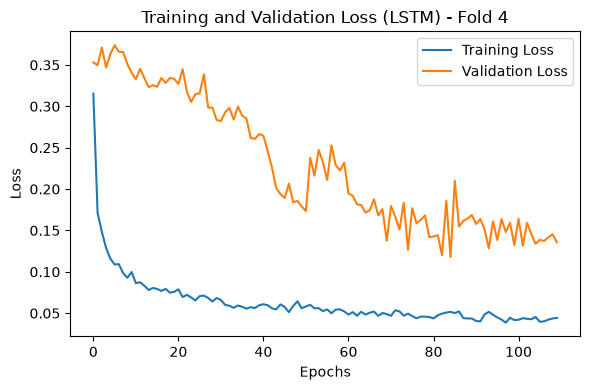

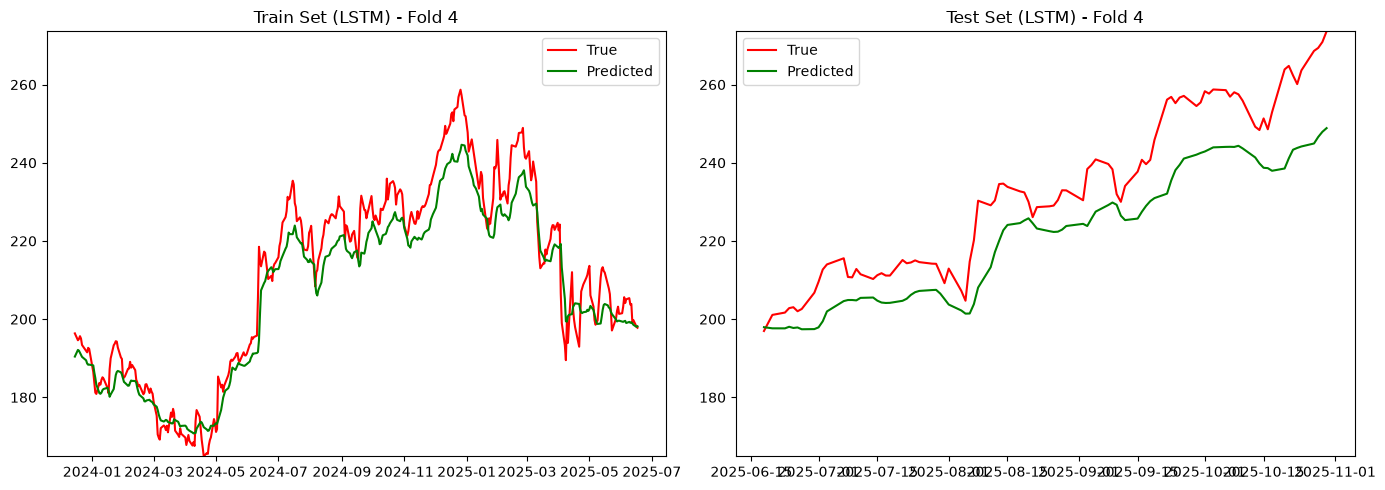

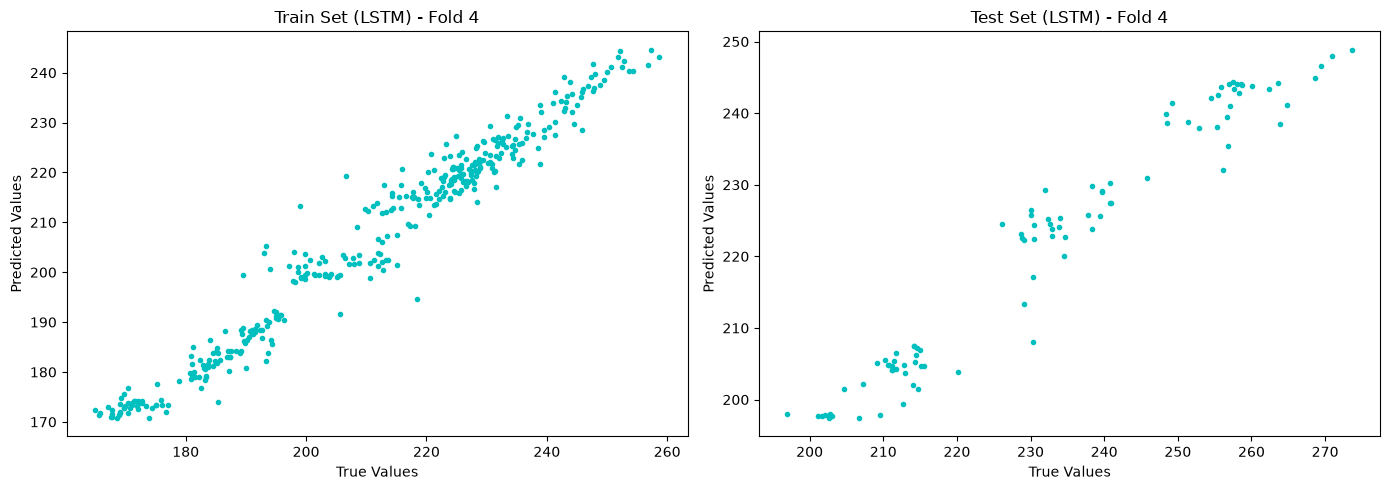

In [55]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# Define the LSTM model building function
def build_lstm_model(window_size, num_features, dropout_rate=0.2, learning_rate=0.001):
    model = Sequential([
        Input(shape=(window_size, num_features)),
        LSTM(64, return_sequences=True),
        Dropout(dropout_rate),
        BatchNormalization(),
        LSTM(32, return_sequences=False),
        Dropout(dropout_rate),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mae')
    return model

# Re-initialize TimeSeriesSplit
n_splits = 5
kf_time_series = TimeSeriesSplit(n_splits=n_splits)

# X_recent_2d was already created in cell 5fe8341e
# We will iterate to get the 4th fold's indices

selected_fold = 4
current_fold = 0

for train_index, test_index in kf_time_series.split(X_recent_2d):
    current_fold += 1
    if current_fold == selected_fold:
        # Store the indices for the selected fold
        train_index_4 = train_index
        test_index_4 = test_index
        break

print(f"Extracted indices for Fold {selected_fold}")

# Extract data for Fold 4
X_train_fold_4_2d = X_recent_2d[train_index_4]
X_test_fold_4_2d  = X_recent_2d[test_index_4]
y_train_fold_4    = y_recent[train_index_4]
y_test_fold_4     = y_recent[test_index_4]
dates_train_fold_4 = dates_recent[train_index_4]
dates_test_fold_4  = dates_recent[test_index_4]

# Scale data for Fold 4
scaler_X_fold_4 = MinMaxScaler(feature_range=(0, 1))
scaler_y_fold_4 = MinMaxScaler(feature_range=(0, 1))

X_train_scaled_fold_4_2d = scaler_X_fold_4.fit_transform(X_train_fold_4_2d)
X_test_scaled_fold_4_2d  = scaler_X_fold_4.transform(X_test_fold_4_2d)

y_train_scaled_fold_4 = scaler_y_fold_4.fit_transform(y_train_fold_4.reshape(-1, 1))
y_test_scaled_fold_4  = scaler_y_fold_4.transform(y_test_fold_4.reshape(-1, 1))

# Reshape scaled X data to 3D for LSTM input
current_window_size = X_recent.shape[1] # This should be 10
current_num_features = X_recent.shape[2] # This should be 5

X_train_scaled_3d_fold_4 = X_train_scaled_fold_4_2d.reshape((X_train_scaled_fold_4_2d.shape[0], current_window_size, current_num_features))
X_test_scaled_3d_fold_4  = X_test_scaled_fold_4_2d.reshape((X_test_scaled_fold_4_2d.shape[0], current_window_size, current_num_features))

print("Data for Fold 4 prepared and scaled.")

# Build a fresh model for Fold 4
model_lstm_fold_4 = build_lstm_model(
    current_window_size,
    current_num_features,
    dropout_rate=0.2,
    learning_rate=0.001 # Use the optimized learning rate
)

# Early stopping callback
early_stopping_fold_4 = EarlyStopping(
    monitor='val_loss',
    patience=25,
    restore_best_weights=True
)

print(f"\nTraining model for Fold {selected_fold}...")
history_lstm_fold_4 = model_lstm_fold_4.fit(
    X_train_scaled_3d_fold_4, y_train_scaled_fold_4,
    epochs=250,
    batch_size=64,
    validation_data=(X_test_scaled_3d_fold_4, y_test_scaled_fold_4),
    verbose=1,
    callbacks=[early_stopping_fold_4]
)

print(f"\nEvaluation for Fold {selected_fold}:")
# Get predictions
y_train_pred_scaled_fold_4 = model_lstm_fold_4.predict(X_train_scaled_3d_fold_4)
y_test_pred_scaled_fold_4  = model_lstm_fold_4.predict(X_test_scaled_3d_fold_4)

# Inverse transform predictions to original scale
y_train_pred_fold_4 = scaler_y_fold_4.inverse_transform(y_train_pred_scaled_fold_4)
y_test_pred_fold_4  = scaler_y_fold_4.inverse_transform(y_test_pred_scaled_fold_4)

# Calculate metrics
r2_train_fold_4 = r2_score(y_train_fold_4, y_train_pred_fold_4)
r2_test_fold_4  = r2_score(y_test_fold_4, y_test_pred_fold_4)

rmse_train_fold_4 = mean_squared_error(y_train_fold_4, y_train_pred_fold_4)**0.5
rmse_test_fold_4  = mean_squared_error(y_test_fold_4, y_test_pred_fold_4)**0.5

mae_train_fold_4 = mean_absolute_error(y_train_fold_4, y_train_pred_fold_4)
mae_test_fold_4  = mean_absolute_error(y_test_fold_4, y_test_pred_fold_4)

print("MAE:")
print(f"  Train: {mae_train_fold_4:.4f}")
print(f"  Test:  {mae_test_fold_4:.4f}")
print("R^2:")
print(f"  Train: {r2_train_fold_4:.4f}")
print(f"  Test:  {r2_test_fold_4:.4f}")

# Plotting for Fold 4
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.plot(history_lstm_fold_4.history['loss'], label='Training Loss')
ax.plot(history_lstm_fold_4.history['val_loss'], label='Validation Loss')
ax.set_title(f'Training and Validation Loss (LSTM) - Fold {selected_fold}')
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.legend()
plt.tight_layout()
plt.show()

y_train_pred_series_fold_4 = pd.Series(y_train_pred_fold_4.flatten(), index=dates_train_fold_4)
y_test_pred_series_fold_4  = pd.Series(y_test_pred_fold_4.flatten(), index=dates_test_fold_4)

y_min_fold_4 = min(y_train_fold_4.min(), y_train_pred_series_fold_4.min(), y_test_fold_4.min(), y_test_pred_series_fold_4.min())
y_max_fold_4 = max(y_train_fold_4.max(), y_train_pred_series_fold_4.max(), y_test_fold_4.max(), y_test_pred_series_fold_4.max())

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(dates_train_fold_4, y_train_fold_4, 'r', label='True')
axs[0].plot(y_train_pred_series_fold_4, 'g', label='Predicted')
axs[0].set_title(f'Train Set (LSTM) - Fold {selected_fold}')
axs[0].set_ylim(y_min_fold_4, y_max_fold_4)
axs[0].legend()

axs[1].plot(dates_test_fold_4, y_test_fold_4, 'r', label='True')
axs[1].plot(y_test_pred_series_fold_4, 'g', label='Predicted')
axs[1].set_title(f'Test Set (LSTM) - Fold {selected_fold}')
axs[1].set_ylim(y_min_fold_4, y_max_fold_4)
axs[1].legend()

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(y_train_fold_4, y_train_pred_series_fold_4.values, 'c.')
axs[0].set_title(f'Train Set (LSTM) - Fold {selected_fold}')
axs[0].set_xlabel('True Values')
axs[0].set_ylabel('Predicted Values')

axs[1].plot(y_test_fold_4, y_test_pred_series_fold_4.values, 'c.')
axs[1].set_title(f'Test Set (LSTM) - Fold {selected_fold}')
axs[1].set_xlabel('True Values')
axs[1].set_ylabel('Predicted Values')

plt.tight_layout()
plt.show()

### Saving the Trained Model for Specific Fold (e.g., Fold 4)

Now, we will save the `model_lstm_fold_4` which was specifically trained and evaluated on **Fold 4**. This allows you to retain the model's weights and configuration from this particular cross-validation split.

In [56]:
import joblib
model_lstm_fold_4.save('lstm_model_fold_4.keras')
print("LSTM model for Fold 4 saved as 'lstm_model_fold_4.keras'")

# Save the X scaler specific to Fold 4
joblib.dump(scaler_X_fold_4, 'scaler_X_fold_4.pkl')
print("X scaler for Fold 4 saved as 'scaler_X_fold_4.pkl'")

# Save the y scaler specific to Fold 4
joblib.dump(scaler_y_fold_4, 'scaler_y_fold_4.pkl')
print("Y scaler for Fold 4 saved as 'scaler_y_fold_4.pkl'")

LSTM model for Fold 4 saved as 'lstm_model_fold_4.keras'
X scaler for Fold 4 saved as 'scaler_X_fold_4.pkl'
Y scaler for Fold 4 saved as 'scaler_y_fold_4.pkl'


### MLflow Tracking Example for LSTM Model

Logging LSTM model's training details, parameters, and performance metrics to MLflow. The results from the `model_lstm_fold_4` which was trained on Fold 4 of the time series cross-validation.

In [57]:
import mlflow
import mlflow.keras
from sklearn.metrics import mean_absolute_error, r2_score

# Set an experiment name for the LSTM model
mlflow.set_experiment("Stock Price Prediction - LSTM Model")

with mlflow.start_run():
    # Log parameters specific to the LSTM model (from build_lstm_model and training for Fold 4)
    mlflow.log_param("epochs", 250)
    mlflow.log_param("batch_size", 64)
    mlflow.log_param("dropout_rate", 0.2)
    mlflow.log_param("learning_rate", 0.001)
    mlflow.log_param("loss_function", "mae")
    mlflow.log_param("window_size", 10)
    mlflow.log_param("num_features", X_recent.shape[2]) # Get from X_recent as used in CV

    # Log metrics (using the results from the Fold 4 evaluation)
    mlflow.log_metric("train_mae", mae_train_fold_4)
    mlflow.log_metric("test_mae", mae_test_fold_4)
    mlflow.log_metric("train_r2", r2_train_fold_4)
    mlflow.log_metric("test_r2", r2_test_fold_4)
    mlflow.log_metric("train_rmse", rmse_train_fold_4)
    mlflow.log_metric("test_rmse", rmse_test_fold_4)

    # Log the Keras LSTM model for Fold 4
    mlflow.keras.log_model(model_lstm_fold_4, "lstm_model_fold_4")

    print("MLflow Run for LSTM model completed.")

2026/06/18 19:02:40 INFO mlflow.tracking.fluent: Experiment with name 'Stock Price Prediction - LSTM Model' does not exist. Creating a new experiment.
2026/06/18 19:02:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/18 19:02:41 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


MLflow Run for LSTM model completed.


In [63]:
import mlflow
import mlflow.keras
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score
import tensorflow as tf

mlflow.set_experiment("Stock Price Prediction - LSTM Model")

# ── Custom callback to log per-epoch metrics ──────────────────────
class MLflowEpochLogger(tf.keras.callbacks.Callback):
    def __init__(self, fold=None):
        self.fold = fold

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        prefix = f"fold_{self.fold}_" if self.fold is not None else ""
        mlflow.log_metric(f"{prefix}train_loss", logs.get("loss", 0),     step=epoch)
        mlflow.log_metric(f"{prefix}val_loss",   logs.get("val_loss", 0), step=epoch)
        mlflow.log_metric(f"{prefix}train_mae",  logs.get("mae", 0),      step=epoch)
        mlflow.log_metric(f"{prefix}val_mae",    logs.get("val_mae", 0),  step=epoch)

# ── Parent run: wraps all folds ───────────────────────────────────
with mlflow.start_run(run_name="LSTM_CV_All_Folds") as parent_run:

    # Log shared hyperparameters once on the parent
    mlflow.log_params({
        "epochs":        250,
        "batch_size":    64,
        "dropout_rate":  0.2,
        "learning_rate": 0.001,
        "loss_function": "mae",
        "window_size":   10,
        "num_features":  X_recent.shape[2],
        "architecture":  "LSTM(64,ret_seq=True)->BN->Drop(0.2)->LSTM(32)->Drop(0.2)->Dense(32,relu)->Dense(1)"
    })

    # ── Per-fold child runs ───────────────────────────────────────
    fold_results = []

    # The model expects 3D scaled data, and was trained on scaled y.
    # The enumeration now passes the scaled X and scaled y for training,
    # and the original unscaled y values for metric calculation.
    # It also passes the scaler_y_fold_4 to inverse transform predictions.
    for fold_idx, (current_model, X_tr_scaled, y_tr_scaled, X_te_scaled, y_te_scaled, y_tr_original, y_te_original, current_scaler_y) in enumerate([
        (model_lstm_fold_4, X_train_scaled_3d_fold_4, y_train_scaled_fold_4, X_test_scaled_3d_fold_4, y_test_scaled_fold_4, y_train_fold_4, y_test_fold_4, scaler_y_fold_4),
        # Add other folds here if available, following the same pattern:
        # (model_lstm_fold_1, X_train_scaled_3d_fold_1, y_train_scaled_fold_1, X_test_scaled_3d_fold_1, y_test_scaled_fold_1, y_train_fold_1, y_test_fold_1, scaler_y_fold_1),
    ], start=4):  # start=4 since you're logging fold 4 first

        with mlflow.start_run(run_name=f"Fold_{fold_idx}", nested=True):

            # Re-train with the epoch logger so steps are recorded
            # Use scaled X and y data for training
            history = current_model.fit(
                X_tr_scaled, y_tr_scaled,
                validation_data=(X_te_scaled, y_te_scaled),
                epochs=250, # Hyperparameter from parent run
                batch_size=64, # Hyperparameter from parent run
                verbose=0,
                callbacks=[
                    tf.keras.callbacks.EarlyStopping(patience=25, restore_best_weights=True),
                    MLflowEpochLogger(fold=fold_idx)
                ]
            )

            # Final evaluation metrics
            # Predictions are scaled, so inverse transform them
            scaled_train_pred = current_model.predict(X_tr_scaled, verbose=0)
            scaled_test_pred  = current_model.predict(X_te_scaled, verbose=0)

            train_pred = current_scaler_y.inverse_transform(scaled_train_pred).flatten()
            test_pred  = current_scaler_y.inverse_transform(scaled_test_pred).flatten()

            # Calculate metrics using original unscaled true values
            mae_train = mean_absolute_error(y_tr_original, train_pred)
            mae_test  = mean_absolute_error(y_te_original, test_pred)
            r2_train  = r2_score(y_tr_original, train_pred)
            r2_test   = r2_score(y_te_original, test_pred)
            rmse_train = np.sqrt(np.mean((y_tr_original - train_pred)**2))
            rmse_test  = np.sqrt(np.mean((y_te_original - test_pred)**2))

            mlflow.log_metrics({
                "final_train_mae":  mae_train,
                "final_test_mae":   mae_test,
                "final_train_r2":   r2_train,
                "final_test_r2":    r2_test,
                "final_train_rmse": rmse_train,
                "final_test_rmse":  rmse_test,
                "epochs_trained":   len(history.history["loss"])
            })

            mlflow.keras.log_model(current_model, f"lstm_model_fold_{fold_idx}")

            fold_results.append({
                "mae_test": mae_test, "r2_test": r2_test, "rmse_test": rmse_test
            })
            print(f"Fold {fold_idx} → test_mae={mae_test:.4f}, test_r2={r2_test:.4f}")

    # ── Log CV summary metrics on parent run ──────────────────────
    mlflow.log_metrics({
        "cv_mean_test_mae":  np.mean([r["mae_test"]  for r in fold_results]),
        "cv_std_test_mae":   np.std( [r["mae_test"]  for r in fold_results]),
        "cv_mean_test_r2":   np.mean([r["r2_test"]   for r in fold_results]),
        "cv_mean_test_rmse": np.mean([r["rmse_test"] for r in fold_results]),
    })

    print("\nMLflow parent run completed with all folds.")

2026/06/18 19:15:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/18 19:15:26 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


Fold 4 → test_mae=8.6635, test_r2=0.7532

MLflow parent run completed with all folds.


In [60]:
print(history.history.keys())

dict_keys(['loss', 'val_loss'])


Verify if the tunnel is still alive and the UI can actually reach the run

In [66]:
import subprocess, time

subprocess.run("pkill -f mlflow", shell=True)
subprocess.run("pkill -f cloudflared", shell=True)
subprocess.run("pkill -f proxy.py", shell=True)
time.sleep(3)
print("Environment cleaned.")

Environment cleaned.


In [67]:
import subprocess, time, re, requests

# ── 1. Kill everything ────────────────────────────────────────────
subprocess.run("pkill -f mlflow", shell=True)
subprocess.run("pkill -f cloudflared", shell=True)
subprocess.run("pkill -f proxy.py", shell=True)
time.sleep(4)

# ── 2. Download and install cloudflared ───────────────────────────
print("Downloading cloudflared...")
subprocess.run("wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared", shell=True)
subprocess.run("chmod +x cloudflared", shell=True)
print("cloudflared installed.")

# Use the sqlite backend for stability and point directly to port 5000
subprocess.Popen(
    ["mlflow", "server", "--backend-store-uri", "sqlite:///mlflow.db", "--artifacts-destination", "./mlruns", "--serve-artifacts",  "--host",  "0.0.0.0", "--port", "5000"],
    stdout=subprocess.DEVNULL, stderr=subprocess.STDOUT
)
print("Waiting for MLflow (sqlite mode)...")
time.sleep(10)


# ── 4. Write proxy ────────────────────────────────────────────────
proxy_code = """
import http.server, urllib.request, urllib.error

class Proxy(http.server.BaseHTTPRequestHandler):
    def _proxy(self, body=None):
        url = f"http://localhost:5000{self.path}"
        headers = {k: v for k, v in self.headers.items()}
        headers["Host"] = "localhost:5000"
        req = urllib.request.Request(url, headers=headers, method=self.command, data=body)
        try:
            resp = urllib.request.urlopen(req)
            self.send_response(resp.status)
            for k, v in resp.headers.items():
                self.send_header(k, v)
            self.end_headers()
            self.wfile.write(resp.read())
        except urllib.error.HTTPError as e:
            self.send_response(e.code)
            self.end_headers()
            self.wfile.write(e.read())
        except Exception as e:
            self.send_response(502)
            self.end_headers()
            self.wfile.write(str(e).encode())

    def do_GET(self):    self._proxy()
    def do_POST(self):
        length = int(self.headers.get("Content-Length", 0))
        self._proxy(self.rfile.read(length))
    def do_PUT(self):
        length = int(self.headers.get("Content-Length", 0))
        self._proxy(self.rfile.read(length))
    def do_DELETE(self): self._proxy()
    def log_message(self, *args): pass

server = http.server.HTTPServer(('0.0.0.0', 5001), Proxy)
server.serve_forever()
"""

with open("proxy.py", "w") as f:
    f.write(proxy_code)

subprocess.Popen(["python", "proxy.py"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
print("Proxy started on port 5001...")
time.sleep(4)

# ── 5. Start Cloudflare tunnel ────────────────────────────────────
proc = subprocess.Popen(
    ["./cloudflared", "tunnel", "--url", "http://localhost:5001"],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT
)

# ── 6. Capture URL from output ────────────────────────────────────
public_url = None
print("Waiting for Cloudflare tunnel...")
for line in proc.stdout:
    line = line.decode()
    if "trycloudflare.com" in line:
        match = re.search(r'https://[a-zA-Z0-9\-]+\.trycloudflare\.com', line)
        if match:
            public_url = match.group()
            break

if not public_url:
    print(" Could not extract tunnel URL.")
else:
    # ── 7. Wait for DNS to propagate before printing ──────────────
    print(f"Tunnel established. Waiting for DNS to propagate...")
    time.sleep(20)  # Cloudflare DNS takes 15-20s to go live

    # ── 8. Verify tunnel is actually reachable ────────────────────
    for attempt in range(10):
        try:
            r = requests.get(public_url, timeout=10)
            print(f"\n MLflow UI is live: {public_url}\n")
            break
        except Exception as e:
            print(f"Not reachable yet (attempt {attempt+1}/10): {e}")
            time.sleep(10)
    else:
        print(f"\n Tunnel URL printed but may still be propagating: {public_url}")
        print("Wait 30 more seconds then try opening it manually.")

cloudflared installed.
Waiting for MLflow (sqlite mode)...
Proxy started on port 5001...
Waiting for Cloudflare tunnel...
Tunnel established. Waiting for DNS to propagate...

 MLflow UI is live: https://squad-challenged-workers-fantasy.trycloudflare.com



Check if runs is logged into experiments

In [68]:
import requests

runs = requests.post(
    "http://localhost:5001/api/2.0/mlflow/runs/search",
    json={"experiment_ids": ["1"], "max_results": 50}
).json()

print(f"Number of runs: {len(runs.get('runs', []))}")
for run in runs.get('runs', []):
    info = run['info']
    metrics = run.get('data', {}).get('metrics', [])
    print(f"\nRun ID: {info['run_id']}")
    print(f"Status: {info['status']}")
    print(f"Metrics: {metrics}")

Number of runs: 5

Run ID: 2f126994c8ba441e9d5ac08d1eefe8e0
Status: FINISHED
Metrics: [{'key': 'fold_4_train_loss', 'value': 0.03766033053398132, 'timestamp': 1781810126158, 'step': 30}, {'key': 'fold_4_val_loss', 'value': 0.12061133235692978, 'timestamp': 1781810126168, 'step': 30}, {'key': 'fold_4_train_mae', 'value': 0.0, 'timestamp': 1781810126178, 'step': 30}, {'key': 'fold_4_val_mae', 'value': 0.0, 'timestamp': 1781810126188, 'step': 30}, {'key': 'final_train_mae', 'value': 4.605054972817843, 'timestamp': 1781810126324, 'step': 0}, {'key': 'final_test_mae', 'value': 8.663515897966198, 'timestamp': 1781810126324, 'step': 0}, {'key': 'final_train_r2', 'value': 0.9414936722686699, 'timestamp': 1781810126324, 'step': 0}, {'key': 'final_test_r2', 'value': 0.7532132441219823, 'timestamp': 1781810126324, 'step': 0}, {'key': 'final_train_rmse', 'value': 5.750313361349597, 'timestamp': 1781810126324, 'step': 0}, {'key': 'final_test_rmse', 'value': 10.28489499423933, 'timestamp': 178181012

tells us if the LSTM_Fold4_epoch_history run with epoch-level metrics is actually in the db.

In [73]:
import requests

runs = requests.post(
    "http://localhost:5001/api/2.0/mlflow/runs/search",
    json={"experiment_ids": ["1"], "max_results": 50}
).json()

for run in runs.get("runs", []):
    info = run["info"]
    metrics = run.get("data", {}).get("metrics", [])
    params  = run.get("data", {}).get("params", [])
    print(f"Run: {info['run_name']} | ID: {info['run_id']} | Metrics: {len(metrics)} | Params: {len(params)}")

Run: Fold_4 | ID: 2f126994c8ba441e9d5ac08d1eefe8e0 | Metrics: 11 | Params: 0
Run: LSTM_CV_All_Folds | ID: e79ed70cdb9d413e870002d1e53a29f9 | Metrics: 4 | Params: 8
Run: Fold_4 | ID: b38411bfaf98494ca62bf3a71bbfc159 | Metrics: 11 | Params: 0
Run: LSTM_CV_All_Folds | ID: b9b916946ea748c1a3ac632b14447b58 | Metrics: 4 | Params: 8
Run: ambitious-crab-496 | ID: 44b1d5f12e214d4284081511f5f2cd7f | Metrics: 6 | Params: 7


Check if ML server is still responding

In [81]:
import requests

# Check if MLflow server is still responding
try:
    r = requests.get("http://localhost:5001/health", timeout=5)
    print("Health:", r.status_code, r.text)
except Exception as e:
    print("Server down:", e)

# Check if runs are still in DB
try:
    r = requests.post(
        "http://localhost:5001/api/2.0/mlflow/runs/search",
        json={"experiment_ids": ["1"], "max_results": 50}
    ).json()
    print("Runs found:", len(r.get("runs", [])))
except Exception as e:
    print("Runs search failed:", e)

Health: 200 OK
Runs found: 5


In [83]:
# Check if the server is actually responding
!curl -X POST http://localhost:5001/api/2.0/mlflow/experiments/search \
  -H "Content-Type: application/json" \
  -d '{"max_results": 100}'

{
  "experiments": [
    {
      "experiment_id": "1",
      "name": "Stock Price Prediction - LSTM Model",
      "artifact_location": "/content/Predictive-Analytics-Public-Datasets/mlruns/1",
      "lifecycle_stage": "active",
      "last_update_time": 1781809360830,
      "creation_time": 1781809360830,
      "workspace": "default"
    },
    {
      "experiment_id": "0",
      "name": "Default",
      "artifact_location": "mlflow-artifacts:/0",
      "lifecycle_stage": "active",
      "last_update_time": 1781808752215,
      "creation_time": 1781808752215,
      "workspace": "default"
    }
  ]
}

Check if the tunnel is still live

In [76]:
import requests

# Replace with your current trycloudflare.com URL
PUBLIC_URL = "https://xxxx.trycloudflare.com"

try:
    r = requests.get(f"{PUBLIC_URL}/api/2.0/mlflow/experiments/search",
                     json={"max_results": 60}, timeout=60)
    print("Tunnel status:", r.status_code)
except Exception as e:
    print("Tunnel is down:", e)

Tunnel is down: HTTPSConnectionPool(host='xxxx.trycloudflare.com', port=443): Max retries exceeded with url: /api/2.0/mlflow/experiments/search (Caused by NameResolutionError("HTTPSConnection(host='xxxx.trycloudflare.com', port=443): Failed to resolve 'xxxx.trycloudflare.com' ([Errno -2] Name or service not known)"))


### mlflow for keras

In [77]:
!ps aux | grep mlflow

root      342360  3.3  0.1 2390020 243936 ?      Sl   19:17   0:06 /usr/bin/python3 /usr/local/bin/mlflow server --backend-store-uri sqlite:///mlflow.db --artifacts-destination ./mlruns --serve-artifacts --host 0.0.0.0 --port 5000
root      342412  2.5  0.1 2236880 235020 ?      Sl   19:17   0:04 /usr/bin/python3 -m uvicorn --log-config /usr/local/lib/python3.12/dist-packages/mlflow/server/uvicorn_log_config.yaml --host 0.0.0.0 --port 5000 --workers 4 mlflow.server.fastapi_app:app
root      342413  2.5  0.1 2819684 229828 ?      Sl   19:17   0:04 /usr/bin/python3 -m mlflow.server.jobs._job_runner
root      342515  1.4  0.1 3115468 229488 ?      Sl   19:17   0:02 /usr/bin/python3 -m huey.bin.huey_consumer mlflow.server.jobs._huey_consumer.huey_instance -w 10 -q
root      342517  1.4  0.1 3115528 229628 ?      Sl   19:17   0:02 /usr/bin/python3 -m huey.bin.huey_consumer mlflow.server.jobs._huey_consumer.huey_instance -w 10 -q
root      342518  1.4  0.1 2525480 229636 ?      Sl   19:17   

In [78]:
print('Checking active processes on port 5001:')
!lsof -i :5001
# If lsof is not installed, you can try:
#!netstat -tuln | grep 5000
#!fuser 5000/tcp

Checking active processes on port 5001:
COMMAND    PID USER   FD   TYPE DEVICE SIZE/OFF NODE NAME
python3 343125 root    3u  IPv4 998785      0t0  TCP *:5001 (LISTEN)


In [ ]:
#!ngrok version

Using cloudfare for MLflow, https and avoid the http of ngronk using .app

Checking for MLflow experiment

In [71]:
experiments = mlflow.search_experiments()
print(experiments)
#for exp in experiments:
    #print(f"Name: {exp.name}, Experiment_id: {exp.experiment_id}")

[<Experiment: artifact_location='/content/Predictive-Analytics-Public-Datasets/mlruns/1', creation_time=1781809360830, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1781809360830, lifecycle_stage='active', name='Stock Price Prediction - LSTM Model', tags={}, trace_location=None, workspace='default'>, <Experiment: artifact_location='mlflow-artifacts:/0', creation_time=1781808752215, effective_trace_archival_retention=None, experiment_id='0', last_update_time=1781808752215, lifecycle_stage='active', name='Default', tags={}, trace_location=None, workspace='default'>]


In [82]:
import requests

# Check the specific run directly
run = requests.get(
    "http://localhost:5001/api/2.0/mlflow/runs/get?run_id=3a5ab80c7bff46afb9fde88bffb5a117"
).json()

print("Status:", run["run"]["info"]["status"])
print("Metrics:")
for m in run["run"]["data"]["metrics"]:
    print(f"  {m['key']}: {m['value']}")

KeyError: 'run'

checking artifact location

In [85]:
import requests

runs = requests.post(
    "http://localhost:5001/api/2.0/mlflow/runs/search",
    json={"experiment_ids": ["1"], "max_results": 50}
).json()

for run in runs.get("runs", []):
    info = run["info"]
    print(f"{info['run_name']} | artifact_uri: {info['artifact_uri']}")

Fold_4 | artifact_uri: /content/Predictive-Analytics-Public-Datasets/mlruns/1/2f126994c8ba441e9d5ac08d1eefe8e0/artifacts
LSTM_CV_All_Folds | artifact_uri: /content/Predictive-Analytics-Public-Datasets/mlruns/1/e79ed70cdb9d413e870002d1e53a29f9/artifacts
Fold_4 | artifact_uri: /content/Predictive-Analytics-Public-Datasets/mlruns/1/b38411bfaf98494ca62bf3a71bbfc159/artifacts
LSTM_CV_All_Folds | artifact_uri: /content/Predictive-Analytics-Public-Datasets/mlruns/1/b9b916946ea748c1a3ac632b14447b58/artifacts
ambitious-crab-496 | artifact_uri: /content/Predictive-Analytics-Public-Datasets/mlruns/1/44b1d5f12e214d4284081511f5f2cd7f/artifacts


Switching to a different tunnel without the proxy layer for cloudfare

In [ ]:
import subprocess, re, time, requests

# ── 1. Kill everything ────────────────────────────────────────────
subprocess.run("pkill -f mlflow", shell=True)
subprocess.run("pkill -f cloudflared", shell=True)
subprocess.run("pkill -f proxy.py", shell=True)
time.sleep(4)

# ── 2. Download cloudflared ───────────────────────────────────────
print("Downloading cloudflared...")
subprocess.run("wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared", shell=True)
subprocess.run("chmod +x cloudflared", shell=True)
print("cloudflared installed.")

# ── 3. Start MLflow server ────────────────────────────────────────
subprocess.Popen(
    ["mlflow", "server",
     "--backend-store-uri", "sqlite:///mlflow.db",
     "--serve-artifacts",
     "--host", "0.0.0.0", "--port", "5000"],
    stdout=subprocess.DEVNULL, stderr=subprocess.STDOUT
)

# Poll until ready
print("Waiting for MLflow...")
for i in range(30):
    try:
        r = requests.get("http://localhost:5000/health", timeout=3)
        if r.status_code == 200:
            print(f"MLflow ready after {(i+1)*2}s")
            break
    except Exception:
        pass
    time.sleep(2)

# ── 4. Tunnel directly to MLflow port 5000 ───────────────────────
proc = subprocess.Popen(
    ["./cloudflared", "tunnel", "--url", "http://localhost:5000"],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT
)

print("Waiting for tunnel...")
for line in proc.stdout:
    line = line.decode()
    if "trycloudflare.com" in line:
        match = re.search(r'https://[a-zA-Z0-9\-]+\.trycloudflare\.com', line)
        if match:
            print(f"\n✅ MLflow UI: {match.group()}\n")
            break

Invalid host header

In [ ]:
'''# Invalid host header
import subprocess, time, re, requests

# ── 1. Kill everything ────────────────────────────────────────────
subprocess.run("pkill -f mlflow", shell=True)
subprocess.run("pkill -f cloudflared", shell=True)
subprocess.run("pkill -f proxy.py", shell=True)
time.sleep(4)

# ── 2. Download and install cloudflared ───────────────────────────
print("Downloading cloudflared...")
subprocess.run("wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared", shell=True)
subprocess.run("chmod +x cloudflared", shell=True)
print("cloudflared installed.")

# ── 3. Start MLflow ───────────────────────────────────────────────
# Use the sqlite backend for stability and point directly to port 5000
subprocess.Popen(
    ["mlflow", "server", "--backend-store-uri", "sqlite:///mlflow.db", "--host", "0.0.0.0", "--port", "5000", "--allowed-hosts", "*.trycloudflare.com"],
    stdout=subprocess.DEVNULL, stderr=subprocess.STDOUT
)
print("Waiting for MLflow (sqlite mode)...")
time.sleep(10)

# --- 4 & 5. Remove the proxy and tunnel directly to port 5000 ---
# Skip writing/running proxy.py entirely
print("Starting Cloudflare tunnel directly to port 5000...")
proc = subprocess.Popen(
    ["./cloudflared", "tunnel", "--url", "http://localhost:5000"],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT
)
# ── 6. Capture URL from output ────────────────────────────────────
public_url = None
print("Waiting for Cloudflare tunnel...")
for line in proc.stdout:
    line = line.decode()
    if "trycloudflare.com" in line:
        match = re.search(r'https://[a-zA-Z0-9\-]+\.trycloudflare\.com', line)
        if match:
            public_url = match.group()
            break

if not public_url:
    print(" Could not extract tunnel URL.")
else:
    # ── 7. Wait for DNS to propagate before printing ──────────────
    print(f"Tunnel established. Waiting for DNS to propagate...")
    time.sleep(20)  # Cloudflare DNS takes 15-20s to go live

    # ── 8. Verify tunnel is actually reachable ────────────────────
    for attempt in range(10):
        try:
            r = requests.get(public_url, timeout=10)
            print(f"\n MLflow UI is live: {public_url}\n")
            break
        except Exception as e:
            print(f"Not reachable yet (attempt {attempt+1}/10): {e}")
            time.sleep(10)
    else:
        print(f"\n Tunnel URL printed but may still be propagating: {public_url}")
        print("Wait 30 more seconds then try opening it manually.")'''

In [84]:
import requests
r = requests.get("http://localhost:5001/api/2.0/mlflow/experiments/search?max_results=100")
print(r.json())

{'experiments': [{'experiment_id': '1', 'name': 'Stock Price Prediction - LSTM Model', 'artifact_location': '/content/Predictive-Analytics-Public-Datasets/mlruns/1', 'lifecycle_stage': 'active', 'last_update_time': 1781809360830, 'creation_time': 1781809360830, 'workspace': 'default'}, {'experiment_id': '0', 'name': 'Default', 'artifact_location': 'mlflow-artifacts:/0', 'lifecycle_stage': 'active', 'last_update_time': 1781808752215, 'creation_time': 1781808752215, 'workspace': 'default'}]}


Google proxy for localhost

In [ ]:
from google.colab import output
# Replace 5000 with your MLflow port if different
print(output.eval_js("google.colab.kernel.proxyPort(5001)"))

## Using ngrok

In [ ]:
'''import subprocess
import threading
import time
from pyngrok import ngrok

def run_mlflow_ui():
    # Start MLflow UI in a background process
    print("Starting MLflow UI...")
    mlflow_process = subprocess.Popen(["mlflow", "ui", "--host", "0.0.0.0"], stdout=subprocess.PIPE, stderr=subprocess.PIPE)
    print("MLflow UI process started. Waiting for it to become available...")
    # Give MLflow UI some time to start
    time.sleep(5)
    for _ in range(30):
        if mlflow_process.poll() is not None: # If process exited, something went wrong
            stdout, stderr = mlflow_process.communicate()
            print(f"MLflow UI process exited with code {mlflow_process.returncode}")
            print(f"STDOUT: {stdout.decode()}")
            print(f"STDERR: {stderr.decode()}")
            raise RuntimeError("MLflow UI failed to start.")
        print("Checking for MLflow UI availability...")
        # More robust check could involve trying to connect to the port
        time.sleep(2)
    print("MLflow UI should be running locally now.")
    return mlflow_process

# Run MLflow UI in a separate thread
mlflow_thread = threading.Thread(target=run_mlflow_ui)
mlflow_thread.daemon = True
mlflow_thread.start()

# Wait for MLflow UI to start (adjust sleep time if necessary)
time.sleep(10)

# Create a public URL for the MLflow UI using ngrok
print("Creating ngrok tunnel...")
# The default MLflow UI port is 5000
public_url = ngrok.connect(5000)
print(f"MLflow UI is available at: {public_url}")'''

Using ngronk for MLflow. I need to upgrade to tier model to avoid the http and https handshake problem

In [ ]:
'''import subprocess, requests, time

for attempt in range(10):
    subprocess.run("pkill ngrok", shell=True)
    time.sleep(2)

    subprocess.Popen(
        ["ngrok", "http", "--scheme=https", "5000"],
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL
    )
    time.sleep(5)

    try:
        resp = requests.get("http://localhost:4040/api/tunnels")
        tunnels = resp.json()["tunnels"]
        https_tunnels = [t for t in tunnels if t["public_url"].startswith("https://")]

        if https_tunnels:
            url = https_tunnels[0]["public_url"]
            if ".dev" not in url:  # Reject .dev domains
                print(f" Good domain: {url}")
                break
            else:
                print(f"Got .dev domain ({url}), retrying...")
    except Exception as e:
        print(f"Attempt {attempt+1}: {e}")
else:
    print("Could not get a non-.dev domain after 10 attempts.")'''